In [2]:
import os, sys

# Point PROJ to the db that belongs to THIS conda env
conda_prefix = sys.prefix  # e.g. C:\Coding\envs\soms-tc
os.environ["PROJ_DATA"] = os.path.join(conda_prefix, "Library", "share", "proj")
os.environ["PROJ_NETWORK"] = "OFF"  # avoid fallback to network CDN

#


In [ ]:
"""
aster_preprocess.py
====================
Reprojects and clips ASTER L1T multi-resolution bands to a standard CRS
and an AOI bounding box, then stacks them into a single analysis-ready
datacube (Bands, Y, X) at 15 m resolution.

Why this step is needed
-----------------------
ASTER L1T tiles are delivered in a path-oriented UTM zone that matches the
satellite's orbit track.  The result is a "skewed" image that looks rotated
when displayed on a North-up map.  Reprojecting to a standard UTM or
geographic CRS straightens the image and aligns it with other datasets.

AOI (from NASA AppEARS / EarthData bounding-box widget)
    SW : lat = -16.67392  lon = 33.86904
    NE : lat = -16.16716  lon = 34.52895

Band inventory (ASTER L1T)
    VNIR  B01, B02, B03N   —  15 m
    SWIR  B04 – B09        —  30 m
    TIR   B10 – B14        —  90 m
All bands are resampled to 15 m (the VNIR master grid) so they share
a common pixel alignment.
"""

import glob
import os
import numpy as np
import xarray as xr
import rioxarray as rxr        # pip install rioxarray
from rasterio.crs import CRS
from rasterio.enums import Resampling
from shapely.geometry import box
import geopandas as gpd        # pip install geopandas

# ---------------------------------------------------------------------------
# 1.  CONFIGURATION — edit these to match your data directory and AOI
# ---------------------------------------------------------------------------

DATA_DIR = "Datasets/AST_L1T/"          # folder that contains the ASTER .tif files
OUTPUT_DIR = "output"   # where reprojected / clipped files will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)

# AOI corners in WGS84 (EPSG:4326)
AOI_SW_LAT, AOI_SW_LON = -16.35185, 34.06278   # south-west corner
AOI_NE_LAT, AOI_NE_LON = -16.30118, 34.1258   # north-east corner


# Target CRS — UTM zone 36S is appropriate for Mozambique / Zambia border
# Switch to EPSG:4326 if you prefer geographic degrees
TARGET_CRS = "EPSG:32736"     # WGS 84 / UTM zone 36S

# Target resolution (metres) — match the finest band (VNIR = 15 m)
TARGET_RES_M = 15

# NoData sentinel in the raw ASTER L1T product
NODATA_VALUE = 0

# ---------------------------------------------------------------------------
# 2.  BUILD AOI GEOMETRY IN THE TARGET CRS
# ---------------------------------------------------------------------------

# Start as a WGS84 polygon, then project to TARGET_CRS for pixel-aligned clip
aoi_wgs84 = gpd.GeoDataFrame(
    geometry=[box(AOI_SW_LON, AOI_SW_LAT, AOI_NE_LON, AOI_NE_LAT)],
    crs="EPSG:4326",
)
aoi_target = aoi_wgs84.to_crs(TARGET_CRS)
aoi_geom   = [aoi_target.geometry.values[0]]   # list of shapely geometries

print(f"AOI extent in {TARGET_CRS}:")
print(f"  {aoi_target.total_bounds}")           # (minx, miny, maxx, maxy)

# ---------------------------------------------------------------------------
# 3.  COLLECT INDIVIDUAL BAND FILES  (skip the stacked multi-band TIFs)
# ---------------------------------------------------------------------------

# Only grab files that end with _B##.tif  (single-band files)
band_files = sorted(glob.glob(os.path.join(DATA_DIR, "AST_L1T_*_B*.tif")))

# Also accept B03N
band_files += sorted(glob.glob(os.path.join(DATA_DIR, "AST_L1T_*_B03N.tif")))
band_files = sorted(set(band_files))            # deduplicate

print(f"\nFound {len(band_files)} single-band files:")
for f in band_files:
    print(f"  {os.path.basename(f)}")

# ---------------------------------------------------------------------------
# 4.  REPROJECT  →  CLIP  →  RESAMPLE  each band
# ---------------------------------------------------------------------------

def process_band(file_path: str, target_crs: str,
                 aoi_geom_list, target_res_m: int,
                 nodata: int = 0) -> xr.DataArray:
    """
    Load a single-band ASTER GeoTIFF, reproject to target_crs,
    clip to the AOI polygon, and resample to target_res_m.

    Returns an xr.DataArray with spatial dims (y, x).
    """
    band = rxr.open_rasterio(file_path, masked=True).squeeze("band", drop=True)

    # --- 4a. Reproject to the standard CRS (fixes the skew) ---------------
    #   Resampling.bilinear is fine for reflectance/radiance bands.
    #   Use Resampling.nearest for categorical / classification layers.
    band_reproj = band.rio.reproject(
        target_crs,
        resolution=target_res_m,
        resampling=Resampling.bilinear,
        nodata=nodata,
    )

    # --- 4b. Clip to AOI ---------------------------------------------------
    #   drop=True removes rows/cols that are entirely outside the AOI.
    #   all_touched=False (default) includes only pixels whose centre falls
    #   inside the polygon — more conservative, avoids edge artefacts.
    band_clipped = band_reproj.rio.clip(
        aoi_geom_list,
        crs=target_crs,
        drop=True,
        all_touched=False,
    )

    # --- 4c. Mask the original NoData sentinel (0) -------------------------
    #   rioxarray already handled this via masked=True + nodata kwarg,
    #   but ASTER L1T sometimes stores 0 as a valid reflectance DN.
    #   If that causes problems, comment out the line below.
    band_clipped = band_clipped.where(band_clipped != nodata)

    return band_clipped


processed_bands = []
band_names      = []

for fpath in band_files:
    bname = os.path.basename(fpath)
    print(f"\nProcessing {bname} ...", end=" ", flush=True)

    arr = process_band(
        file_path=fpath,
        target_crs=TARGET_CRS,
        aoi_geom_list=aoi_geom,
        target_res_m=TARGET_RES_M,
        nodata=NODATA_VALUE,
    )

    # Save the individual reprojected+clipped band as a GeoTIFF
    out_path = os.path.join(OUTPUT_DIR, bname.replace(".tif", "_reproj_clip.tif"))
    arr.rio.to_raster(out_path, dtype="float32")
    print(f"saved → {os.path.basename(out_path)}  shape={arr.shape}")

    processed_bands.append(arr)
    band_names.append(bname.split("_B")[-1].replace(".tif", ""))   # e.g. "04"

# ---------------------------------------------------------------------------
# 5.  STACK INTO A DATACUBE  (Bands, Y, X)
# ---------------------------------------------------------------------------
#   All bands now share the same CRS, resolution, and AOI extent, so
#   xr.concat is safe.

print("\nStacking bands into datacube ...")
datacube = xr.concat(processed_bands, dim="band")
datacube["band"] = band_names
print(f"Datacube shape : {datacube.shape}")   # (n_bands, height, width)
print(f"CRS            : {datacube.rio.crs}")
print(f"Spatial extent : {datacube.rio.bounds()}")

# Save the full stacked datacube
cube_path = os.path.join(OUTPUT_DIR, "ASTER_datacube_reproj_clipped.tif")
datacube.rio.to_raster(cube_path, dtype="float32")
print(f"\nDatacube saved → {cube_path}")

# ---------------------------------------------------------------------------
# 6.  PREPARE ML-READY NUMPY ARRAY
# ---------------------------------------------------------------------------
#   Shape after this block: (valid_pixels, n_bands)
#   This is a drop-in replacement for `training_data_1D` in your notebook.

data_yxb = np.moveaxis(datacube.values, 0, -1)         # (Y, X, Bands)

# Normalise each band to [0, 1]
min_vals = np.nanmin(data_yxb, axis=(0, 1), keepdims=True)
max_vals = np.nanmax(data_yxb, axis=(0, 1), keepdims=True)
data_norm = (data_yxb - min_vals) / (max_vals - min_vals + 1e-10)

# Flatten and drop NaN pixels
n_px = data_norm.shape[0] * data_norm.shape[1]
training_data_1D = data_norm.reshape(n_px, -1)
valid_mask_1D    = ~np.isnan(training_data_1D).any(axis=1)
training_data_1D = training_data_1D[valid_mask_1D]

print(f"\nML-ready array : {training_data_1D.shape}")  # (valid_pixels, n_bands)

# Optionally save for fast re-loading
np.save(os.path.join(OUTPUT_DIR, "training_data_1D.npy"), training_data_1D)
np.save(os.path.join(OUTPUT_DIR, "valid_mask_1D.npy"),    valid_mask_1D)
print("Arrays saved as .npy files.")

# ---------------------------------------------------------------------------
# 7.  UTILITY — reconstruct a 2-D map from 1-D cluster labels
# ---------------------------------------------------------------------------
#   After running PCA + KMeans / SOM, call this to get a spatial map.

def labels_to_map(labels_1d: np.ndarray, valid_mask_1d: np.ndarray,
                  spatial_shape: tuple) -> np.ndarray:
    """
    Place cluster labels back into a (height, width) image.

    Parameters
    ----------
    labels_1d   : 1-D array of cluster IDs (length = number of valid pixels)
    valid_mask_1d : boolean mask used to remove NaN pixels before clustering
    spatial_shape : (height, width) of the full AOI raster

    Returns
    -------
    label_map : (height, width) array, NaN where data was masked
    """
    n_px = valid_mask_1d.shape[0]
    full_labels = np.full(n_px, np.nan)
    full_labels[valid_mask_1d] = labels_1d
    return full_labels.reshape(spatial_shape)


# Example usage (uncomment after running PCA + clustering):
# h, w = data_norm.shape[:2]
# label_map = labels_to_map(kmeans_labels, valid_mask_1D, (h, w))

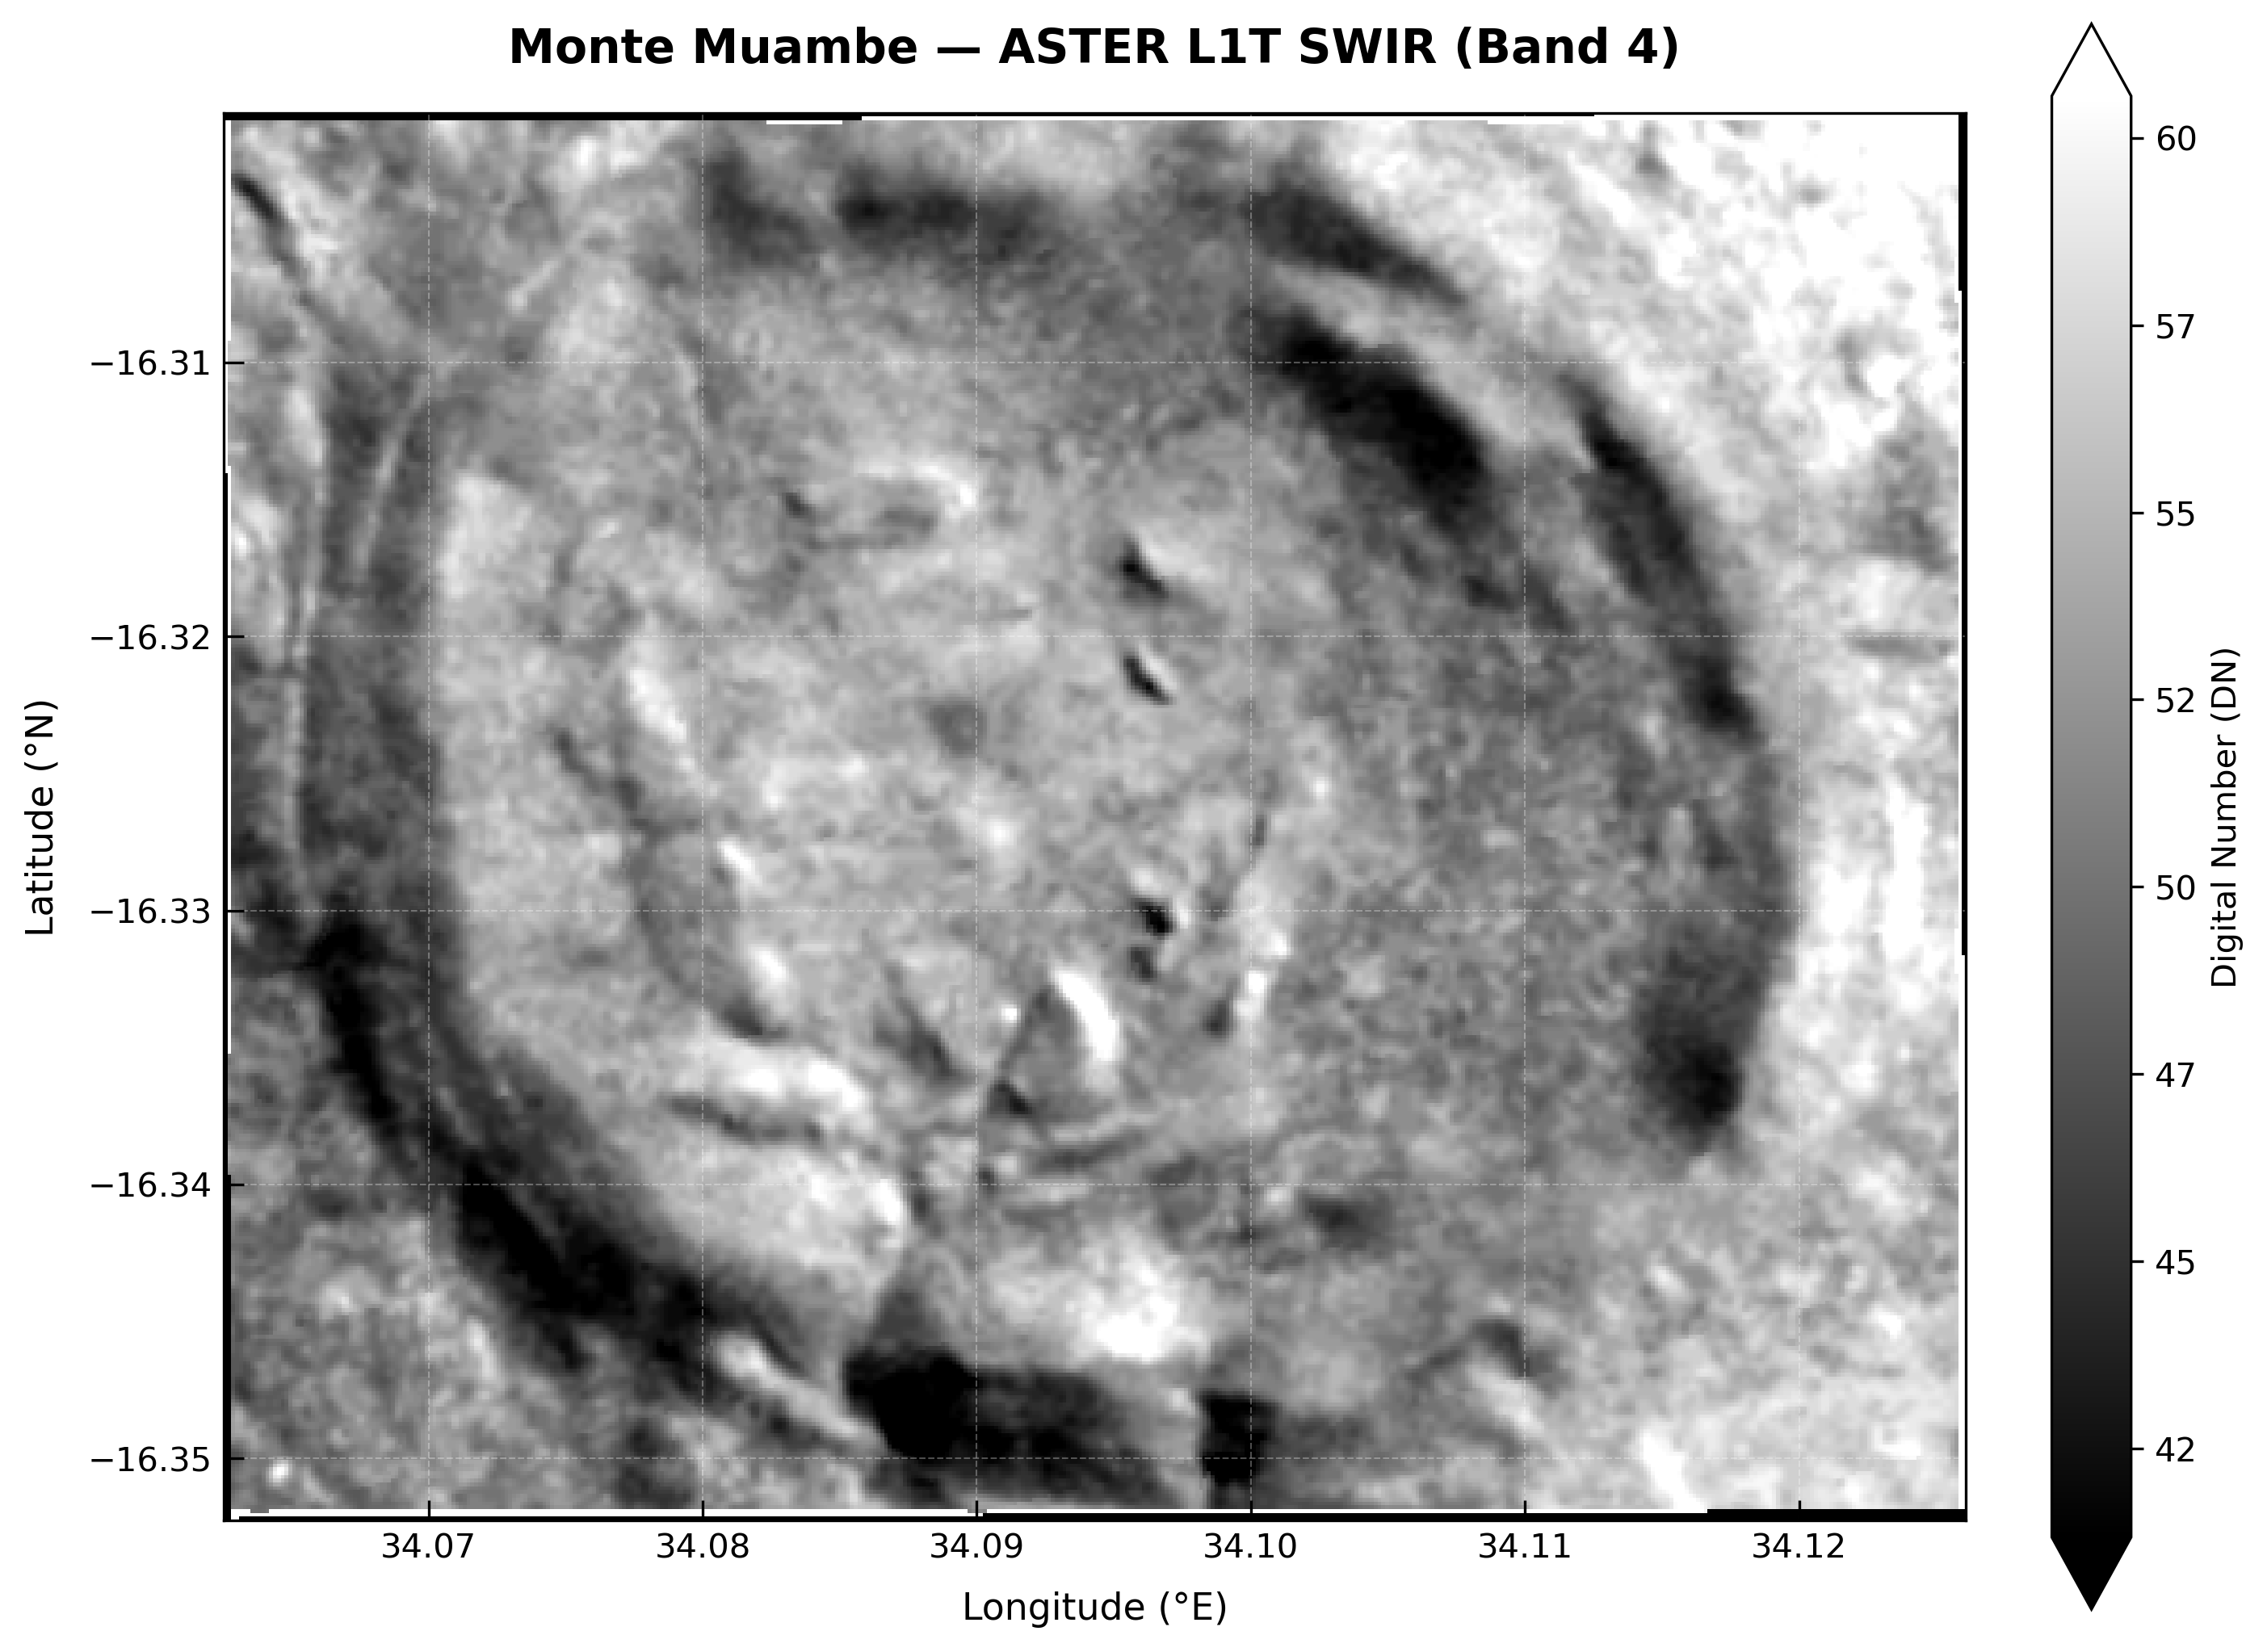

In [8]:
import matplotlib.pyplot as plt
import rioxarray as rxr

# 1. Load the data
file_path = 'output/AST_L1T_00403212007075858_20250607220032_SWIR_B04_reproj_clip.tif'
data_raster = rxr.open_rasterio(file_path).squeeze()

# 2. Force Reprojection to WGS84 (Lat/Lon) if it's currently in UTM meters
# This guarantees your axes show true decimal degrees.
if data_raster.rio.crs and data_raster.rio.crs.to_epsg() != 4326:
    data_raster = data_raster.rio.reproject("EPSG:4326")

# 3. Setup a high-DPI figure for crisp text and lines
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# 4. Plot with advanced cartographic styling
# 'robust=True' automatically calculates the 2nd and 98th percentiles for color scaling.
# This prevents clouds or bad pixels from blowing out the image contrast.
cbar_kwargs = {
    'label': 'Digital Number (DN)', 
    'orientation': 'vertical', 
    'shrink': 0.85,
    'pad': 0.04,
    'format': '%d'
}

im = data_raster.plot(
    ax=ax, 
    cmap='gray',      
    robust=True, 
    cbar_kwargs=cbar_kwargs
)

# 5. Format Axes and Labels for Geoscience Standards
ax.set_title("Monte Muambe — ASTER L1T SWIR (Band 4)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitude (°E)", fontsize=11, labelpad=8)
ax.set_ylabel("Latitude (°N)", fontsize=11, labelpad=8)

# Clean up tick marks and formatting
ax.tick_params(axis='both', which='major', labelsize=10, direction='in', length=6)
ax.tick_params(axis='both', which='minor', direction='in', length=3)

# Add a subtle grid to assist with spatial referencing
ax.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.3)

# Force equal aspect ratio so the volcanic structure isn't stretched
ax.set_aspect('equal')

# 6. Save the figure with tight bounds to avoid cropped labels
plt.tight_layout()
plt.savefig('monte_muambe_swir_b04_publication.png', dpi=300, bbox_inches='tight')
plt.show()

# PCA

In [ ]:
from sklearn.decomposition import PCA
# pca
# Creates PCA with all possible components (3 in this case)
pca = PCA()

# Transforms data to PC space
components = pca.fit_transform(training_data_1D)
# eigenvectors = pca.components_
# eigenvalues = pca.explained_variance_

#Explained Variance Ratio:
#How much of the dataset's total variability each component captures, expressed as a decimal between 0 and 1.
var_ratio = pca.explained_variance_ratio_

var_sum = 0
for i in range(len(var_ratio)):
    if var_sum >= 0.95:
        break
    else:
        var_sum += var_ratio[i]

selected_components = components[:, :i]
print('Number of components:', selected_components.shape[1])
print('var_ratio:',var_ratio)
selected_components # now we have a reduced dataset with only the most informative components, which can be used for clustering or other analyses.

Number of components: 4
var_ratio: [0.7682075  0.10152236 0.07675628 0.0225649  0.00975133 0.00646886
 0.00586508 0.00471074 0.00415304]


array([[ 0.06359601,  0.08399862, -0.07249053, -0.04156044],
       [ 0.10893357,  0.11221448, -0.11829033, -0.00908029],
       [ 0.10739768,  0.05251114, -0.14458874, -0.00783424],
       ...,
       [ 0.6330606 ,  0.4462105 , -0.10661024, -0.05765171],
       [ 0.5742215 ,  0.43390056, -0.05958912, -0.02101546],
       [ 0.4702177 ,  0.3601952 , -0.12353072, -0.0427807 ]],
      dtype=float32)

# K-means and Elbow Methods 
we will use the 4 componets to perform the clustering on.

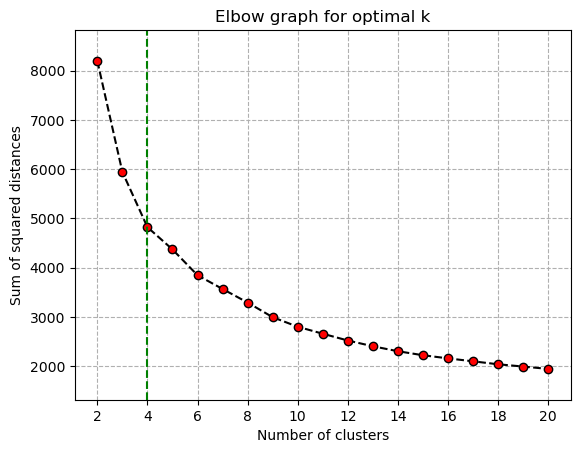

In [14]:
# elbow method
from sklearn import cluster
sum_squared_distance = []
range_n_clusters = range(2, 21)
for k in range_n_clusters:
    clusterer = cluster.KMeans(n_clusters=k, random_state=1)
    clusterer.fit(selected_components)
    sum_squared_distance.append(clusterer.inertia_)

range_ssd = max(sum_squared_distance) - min(sum_squared_distance)

plt.plot(range_n_clusters, sum_squared_distance, 'ko--', mfc='r')
plt.vlines(x=4, ymin=min(sum_squared_distance)-(0.1*range_ssd),
           ymax=max(sum_squared_distance)+(0.1*range_ssd), color='g', linestyles='dashed')
plt.xticks(range(2, 21, 2))
plt.ylim(min(sum_squared_distance)-(0.1*range_ssd), max(sum_squared_distance)+(0.1*range_ssd))
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared distances')
plt.title('Elbow graph for optimal k')
plt.grid(linestyle='--')
plt.savefig('output/pca_kmeans_ASTERL1T_elbow.png', dpi=300)
plt.show()

# visualizer = KElbowVisualizer(cluster.KMeans(random_state=1), k=(2, 21), timings=True)
# # fit the data
# visualizer.fit(selected_components)
# # finalize and render figure
# visualizer.show()

In [15]:
import matplotlib as mpl
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from osgeo import gdal
from osgeo import osr
# import pandas as pd
# import rasterio as rio
import rioxarray as rxr
from scipy.ndimage import generic_filter
from scipy.stats import mode
# import seaborn as sns
# from time import time
from tqdm import tqdm
# from tqdm.notebook import tqdm as tqdm
#from yellowbrick.cluster import KElbowVisualizer

from sklearn import cluster
# from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score, rand_score, adjusted_rand_score
from sklearn.metrics import mutual_info_score, adjusted_mutual_info_score, calinski_harabasz_score, davies_bouldin_score
# from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale
# from sklearn.preprocessing import StandardScaler

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.regularizers import l1

from minisom import MiniSom

In [16]:
# k-means
from statistics import mode

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score


from sklearn.metrics import calinski_harabasz_score


n_clusters = 5
extent = [AOI_SW_LON, AOI_SW_LAT, AOI_NE_LON, AOI_NE_LAT]

# create an object of the classifier
clusterer = cluster.KMeans(n_clusters=n_clusters, random_state=1)
# train
pred = clusterer.fit_predict(selected_components) # Train
# get cluster labels
labels = clusterer.labels_

# Calinski-Harabasz score
ch_score = calinski_harabasz_score(selected_components, labels)
# Davies-Bouldin score
# The minimum score is zero, and the lower values the better clustering performance
db_score = davies_bouldin_score(selected_components, labels)
print('Calinski-Harabasz score:', round(ch_score, 4))
print('Davies-Bouldin score:', round(db_score, 4))

# reshape the labels to a 3D array (single band)
labels = labels.reshape(datacube[0, :, :].shape)

def filter_function(invalues):
    invalues_mode = mode(invalues, axis=None, nan_policy='omit')
    return invalues_mode[0]

labels_major = generic_filter(labels, function=filter_function, size=7)

def plot_map(array, extent, n_clusters):
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.f'))
    plt.yticks(rotation=90, va='center')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.f'))
    cmap = cm.get_cmap('rainbow', n_clusters)
    plt.imshow(array, cmap=cmap, extent=extent)
    cbar = plt.colorbar(label='Cluster Number')
    tick_locs = (np.arange(n_clusters) + 0.5)*(n_clusters-1)/n_clusters
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels(np.arange(n_clusters))
    plt.grid(False)
    # Add axis labels
    plt.xlabel('Longitude (°E)', fontsize=12)
    plt.ylabel('Latitude (°S)', fontsize=12)

    # Add a title
    plt.title('K-Means Clustering Results', fontsize=14)

plot_map(labels_major, extent, n_clusters)

Calinski-Harabasz score: 111701.0118
Davies-Bouldin score: 1.21


ValueError: cannot reshape array of size 167768 into shape (376,451)

Datacube shape : (9, 376, 451)
CRS            : EPSG:32736
Spatial extent : [613522.5, 620272.5, 8191817.5, 8197442.5]
Spatial shape  : (376, 451)
Valid pixels   : 167768 / 169576 (98.9 %)

PCA — keeping 4 components (96.9 % variance explained)
Explained variance per component: [np.float32(0.7682), np.float32(0.1015), np.float32(0.0768), np.float32(0.0226)]


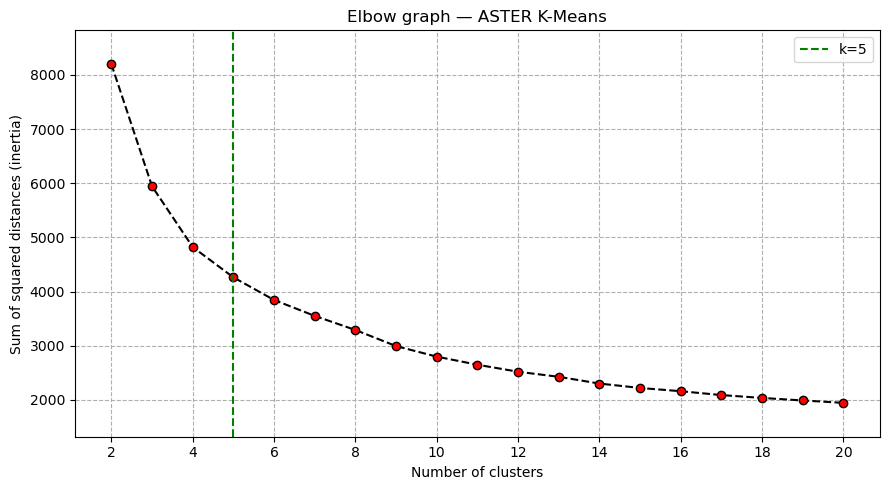


Calinski-Harabasz score : 115555.6094  (higher = better)
Davies-Bouldin score    : 1.1873  (lower  = better)

Label map shape: (376, 451)
Unique clusters: [0 1 2 3 4]
Majority filter applied (kernel=7×7)
Figure saved → output/aster_kmeans_raw.png


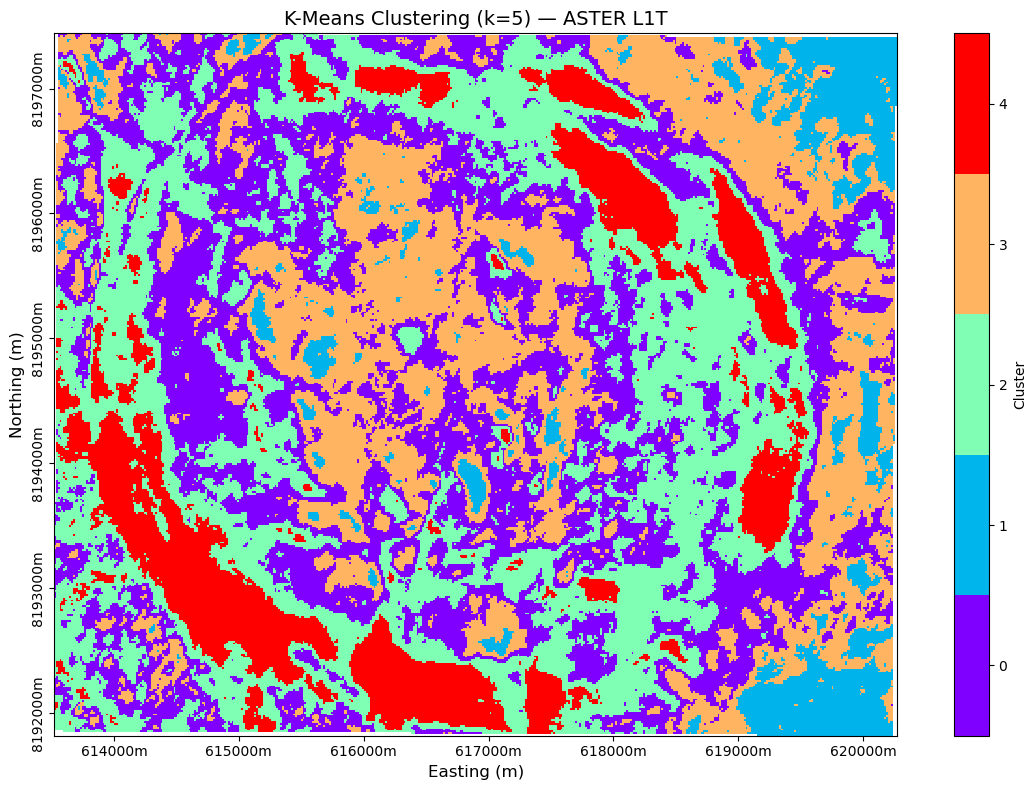

Figure saved → output/aster_kmeans_filtered.png


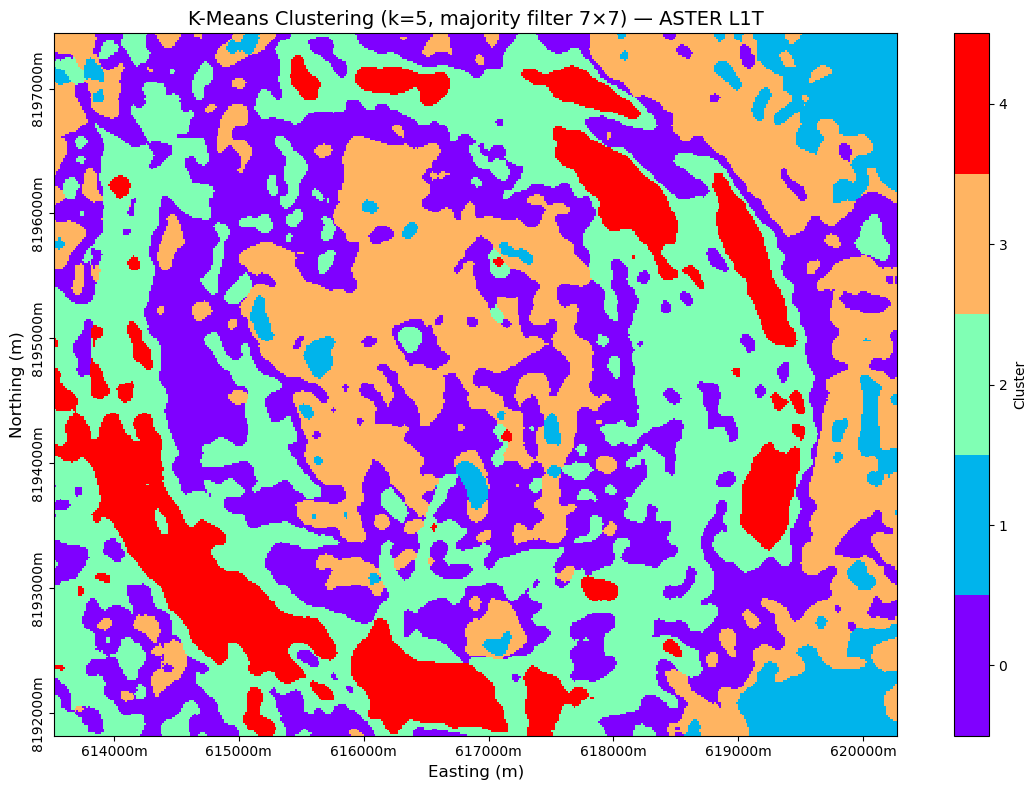

In [17]:
"""
aster_kmeans.py
===============
K-Means clustering on ASTER L1T data after PCA dimensionality reduction.
Adapted from PCA___SOM.ipynb to work with the reprojected/clipped ASTER datacube
produced by aster_preprocess.py.

Key differences from the original Sentinel-2 notebook
------------------------------------------------------
1. ASTER has NaN pixels (NoData + clipped border), so labels must be placed
   back into a spatial array via a valid-pixel mask — the original notebook
   avoided this because Sentinel-2 had no NaN pixels.
2. extent must be derived from the datacube's actual coordinates,
   not from hard-coded WGS84 corners, because after reprojection to
   UTM the x/y axes are in metres.
3. scipy.stats.mode API changed in SciPy ≥ 1.9 — the old
   mode(values)[0][0] idiom now raises a deprecation warning;
   the correct call is mode(values).mode (scalar output).
4. cm.get_cmap is deprecated in matplotlib ≥ 3.7 — use
   matplotlib.colormaps[name] instead.
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.ndimage import generic_filter
from scipy.stats import mode
from sklearn import cluster
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import minmax_scale
import rioxarray as rxr

# ---------------------------------------------------------------------------
# 0.  CONFIGURATION
# ---------------------------------------------------------------------------

DATACUBE_PATH  = "output/ASTER_datacube_reproj_clipped.tif"
OUTPUT_DIR     = "output"
N_CLUSTERS     = 5        # override with your elbow result
FILTER_SIZE    = 7        # majority filter kernel (odd number, e.g. 5, 7, 9)
RANDOM_STATE   = 42
VAR_THRESHOLD  = 0.95     # keep enough PCs to explain this fraction of variance

# ---------------------------------------------------------------------------
# 1.  LOAD THE PREPROCESSED DATACUBE
# ---------------------------------------------------------------------------

datacube = rxr.open_rasterio(DATACUBE_PATH, masked=True)   # (Bands, Y, X)
print(f"Datacube shape : {datacube.shape}")
print(f"CRS            : {datacube.rio.crs}")

# Derive the spatial extent in the datacube's own CRS
# (x and y are in metres for UTM, or degrees for EPSG:4326)
min_x = float(datacube.x.min())
max_x = float(datacube.x.max())
min_y = float(datacube.y.min())
max_y = float(datacube.y.max())
extent = [min_x, max_x, min_y, max_y]          # [left, right, bottom, top]
spatial_shape = (datacube.shape[1], datacube.shape[2])   # (Y, X)

print(f"Spatial extent : {extent}")
print(f"Spatial shape  : {spatial_shape}")

# ---------------------------------------------------------------------------
# 2.  BUILD THE FLAT ML ARRAY  (valid pixels only, no NaN)
# ---------------------------------------------------------------------------

data_yxb = np.moveaxis(datacube.values, 0, -1)            # (Y, X, Bands)

# Normalise each band to [0, 1]  (same as minmax_scale in the notebook)
min_vals = np.nanmin(data_yxb, axis=(0, 1), keepdims=True)
max_vals = np.nanmax(data_yxb, axis=(0, 1), keepdims=True)
data_norm = (data_yxb - min_vals) / (max_vals - min_vals + 1e-10)

# Flatten to (total_pixels, n_bands)
n_px = spatial_shape[0] * spatial_shape[1]
data_flat = data_norm.reshape(n_px, -1)

# Valid-pixel mask  — needed to put labels back into a 2-D map later
valid_mask = ~np.isnan(data_flat).any(axis=1)
data_valid = data_flat[valid_mask]
print(f"Valid pixels   : {data_valid.shape[0]} / {n_px} "
      f"({100*data_valid.shape[0]/n_px:.1f} %)")

# ---------------------------------------------------------------------------
# 3.  PCA
# ---------------------------------------------------------------------------

pca = PCA()
components_all = pca.fit_transform(data_valid)

var_ratio = pca.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)
n_keep    = int(np.searchsorted(cumvar, VAR_THRESHOLD)) + 1
selected_components = components_all[:, :n_keep]

print(f"\nPCA — keeping {n_keep} components "
      f"({100*cumvar[n_keep-1]:.1f} % variance explained)")
print(f"Explained variance per component: "
      f"{[round(v, 4) for v in var_ratio[:n_keep]]}")

# ---------------------------------------------------------------------------
# 4.  ELBOW PLOT
# ---------------------------------------------------------------------------

sum_squared_distance = []
range_n_clusters = range(2, 21)

for k in range_n_clusters:
    km = cluster.KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(selected_components)
    sum_squared_distance.append(km.inertia_)

range_ssd = max(sum_squared_distance) - min(sum_squared_distance)
y_lo = min(sum_squared_distance) - 0.1 * range_ssd
y_hi = max(sum_squared_distance) + 0.1 * range_ssd

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range_n_clusters, sum_squared_distance, 'ko--', mfc='r')
ax.vlines(x=N_CLUSTERS, ymin=y_lo, ymax=y_hi,
          color='g', linestyles='dashed', label=f'k={N_CLUSTERS}')
ax.set_xticks(range(2, 21, 2))
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Sum of squared distances (inertia)')
ax.set_title('Elbow graph — ASTER K-Means')
ax.grid(linestyle='--')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aster_kmeans_elbow.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------
# 5.  K-MEANS  (with the k chosen from the elbow)
# ---------------------------------------------------------------------------

# n_init="auto" silences the FutureWarning in sklearn ≥ 1.2
clusterer = cluster.KMeans(n_clusters=N_CLUSTERS,
                            random_state=RANDOM_STATE,
                            n_init="auto")
labels_valid = clusterer.fit_predict(selected_components)

ch_score = calinski_harabasz_score(selected_components, labels_valid)
db_score = davies_bouldin_score(selected_components, labels_valid)
print(f"\nCalinski-Harabasz score : {ch_score:.4f}  (higher = better)")
print(f"Davies-Bouldin score    : {db_score:.4f}  (lower  = better)")

# ---------------------------------------------------------------------------
# 6.  RECONSTRUCT SPATIAL LABEL MAP  (handles NaN pixels correctly)
# ---------------------------------------------------------------------------

# Fill a full-size flat array with NaN, then place valid labels
labels_full = np.full(n_px, np.nan, dtype=float)
labels_full[valid_mask] = labels_valid

# Reshape to (Y, X)
labels_2d = labels_full.reshape(spatial_shape)
print(f"\nLabel map shape: {labels_2d.shape}")
print(f"Unique clusters: {np.unique(labels_valid)}")

# ---------------------------------------------------------------------------
# 7.  MAJORITY (MODE) FILTER  — smooths speckle noise
#     scipy.stats.mode API: use .mode (not [0][0]) for SciPy >= 1.9
# ---------------------------------------------------------------------------

def filter_function(window_values):
    """
    Majority filter for generic_filter.
    Ignores NaN border pixels so the mask doesn't bleed into valid area.
    """
    valid = window_values[~np.isnan(window_values)]
    if len(valid) == 0:
        return np.nan
    # scipy >= 1.9: mode() returns a scalar directly
    result = mode(valid, keepdims=False)
    return float(result.mode)

labels_major = generic_filter(labels_2d,
                               function=filter_function,
                               size=FILTER_SIZE)
print(f"Majority filter applied (kernel={FILTER_SIZE}×{FILTER_SIZE})")

# ---------------------------------------------------------------------------
# 8.  PLOT
# ---------------------------------------------------------------------------

def plot_map(array, extent, n_clusters, title="K-Means Clustering", save_path=None):
    """
    Render the cluster label map as a colour image.

    Parameters
    ----------
    array      : 2-D numpy array of cluster IDs (NaN = masked)
    extent     : [left, right, bottom, top] in the datacube's CRS
    n_clusters : number of clusters (sets the discrete colormap)
    title      : figure title
    save_path  : if given, saves the figure to this path at 300 dpi
    """
    # matplotlib >= 3.7: cm.get_cmap is deprecated
    try:
        cmap = mpl.colormaps['rainbow'].resampled(n_clusters)
    except AttributeError:
        # fallback for older matplotlib
        cmap = cm.get_cmap('rainbow', n_clusters)

    # Mask NaN so imshow renders them transparent
    array_masked = np.ma.masked_invalid(array)

    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(array_masked,
                   cmap=cmap,
                   vmin=-0.5,
                   vmax=n_clusters - 0.5,
                   extent=extent,
                   origin='upper',
                   interpolation='nearest')

    # Format axis ticks — use decimals for geographic CRS, integers for UTM
    if abs(extent[0]) < 360:          # likely geographic degrees
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f°'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f°'))
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
    else:                              # UTM metres
        ax.xaxis.set_major_formatter(FormatStrFormatter('%dm'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%dm'))
        ax.set_xlabel('Easting (m)', fontsize=12)
        ax.set_ylabel('Northing (m)', fontsize=12)

    plt.yticks(rotation=90, va='center')

    cbar = plt.colorbar(im, ax=ax, label='Cluster')
    tick_locs = np.arange(n_clusters)
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels([str(i) for i in tick_locs])

    ax.set_title(title, fontsize=14)
    ax.grid(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {save_path}")
    plt.show()


# Raw labels
plot_map(labels_2d, extent, N_CLUSTERS,
         title=f"K-Means Clustering (k={N_CLUSTERS}) — ASTER L1T",
         save_path=f"{OUTPUT_DIR}/aster_kmeans_raw.png")

# Majority-filtered labels
plot_map(labels_major, extent, N_CLUSTERS,
         title=f"K-Means Clustering (k={N_CLUSTERS}, majority filter {FILTER_SIZE}×{FILTER_SIZE}) — ASTER L1T",
         save_path=f"{OUTPUT_DIR}/aster_kmeans_filtered.png")

Datacube shape : (9, 376, 451)
CRS            : EPSG:32736
Spatial extent : [613522.5, 620272.5, 8191817.5, 8197442.5]
Spatial shape  : (376, 451)
Valid pixels   : 167768 / 169576 (98.9 %)

PCA — keeping 4 components (96.9 % variance explained)
Explained variance per component: [np.float32(0.7682), np.float32(0.1015), np.float32(0.0768), np.float32(0.0226)]

Running per-k sweep (k=2..20) — silhouette subsample: 10,000 pixels
  k= 2  inertia=      8197.5  sil=0.4031  CH=  159798.8  DB=0.9037
  k= 3  inertia=      5942.8  sil=0.3223  CH=  142041.1  DB=0.9897
  k= 4  inertia=      4821.5  sil=0.3042  CH=  129717.5  DB=1.0565
  k= 5  inertia=      4262.3  sil=0.2532  CH=  115555.6  DB=1.1873
  k= 6  inertia=      3844.6  sil=0.2537  CH=  106131.0  DB=1.1724
  k= 7  inertia=      3550.9  sil=0.2297  CH=   98071.7  DB=1.2262
  k= 8  inertia=      3290.5  sil=0.2342  CH=   92610.6  DB=1.2309
  k= 9  inertia=      2993.6  sil=0.2436  CH=   91150.5  DB=1.1643
  k=10  inertia=      2798.9  sil=0

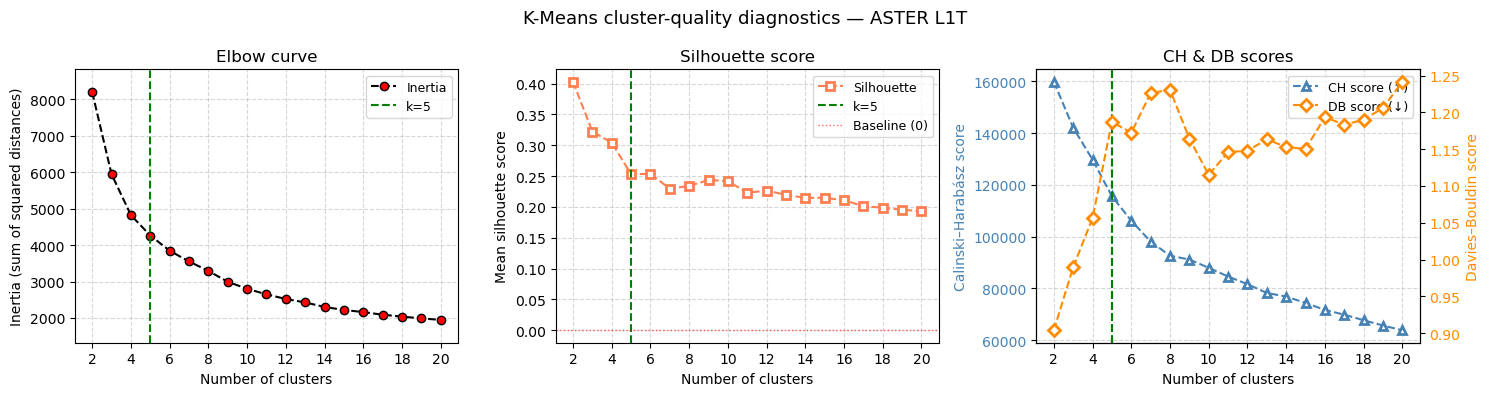

Diagnostic plot saved → output/aster_kmeans_diagnostics.png

── Final model  k=5 ──────────────────────────
Calinski-Harabász : 115555.6094  (higher = better)
Davies-Bouldin    : 1.1873  (lower  = better)
Silhouette (mean) : 0.2532  (range −1 to +1, higher = better)


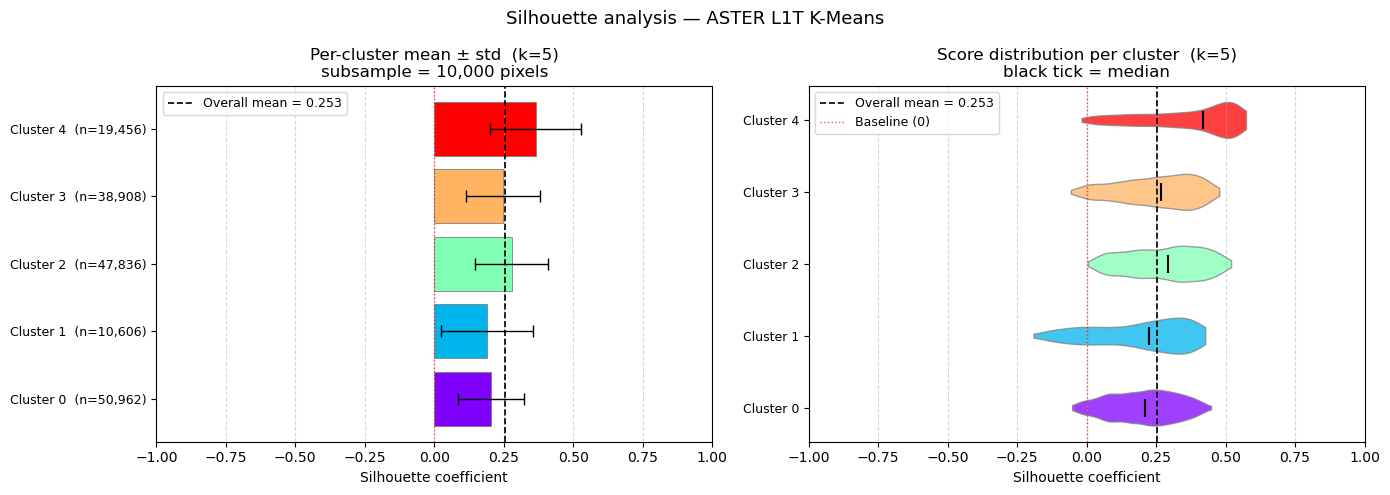

Silhouette plot saved → output/aster_kmeans_silhouette.png

 Cluster    n pixels    sil mean    sil std    sil min    sil max
──────────────────────────────────────────────────────────────
       0      50,962      0.2030     0.1187    -0.0522     0.4478
       1      10,606      0.1902     0.1648    -0.1913     0.4269
       2      47,836      0.2784     0.1312     0.0045     0.5199
       3      38,908      0.2487     0.1334    -0.0568     0.4771
       4      19,456      0.3646     0.1653    -0.0182     0.5735

Label map shape: (376, 451)
Unique clusters: [0 1 2 3 4]
Majority filter applied (kernel=7×7)
Figure saved → output/aster_kmeans_raw.png


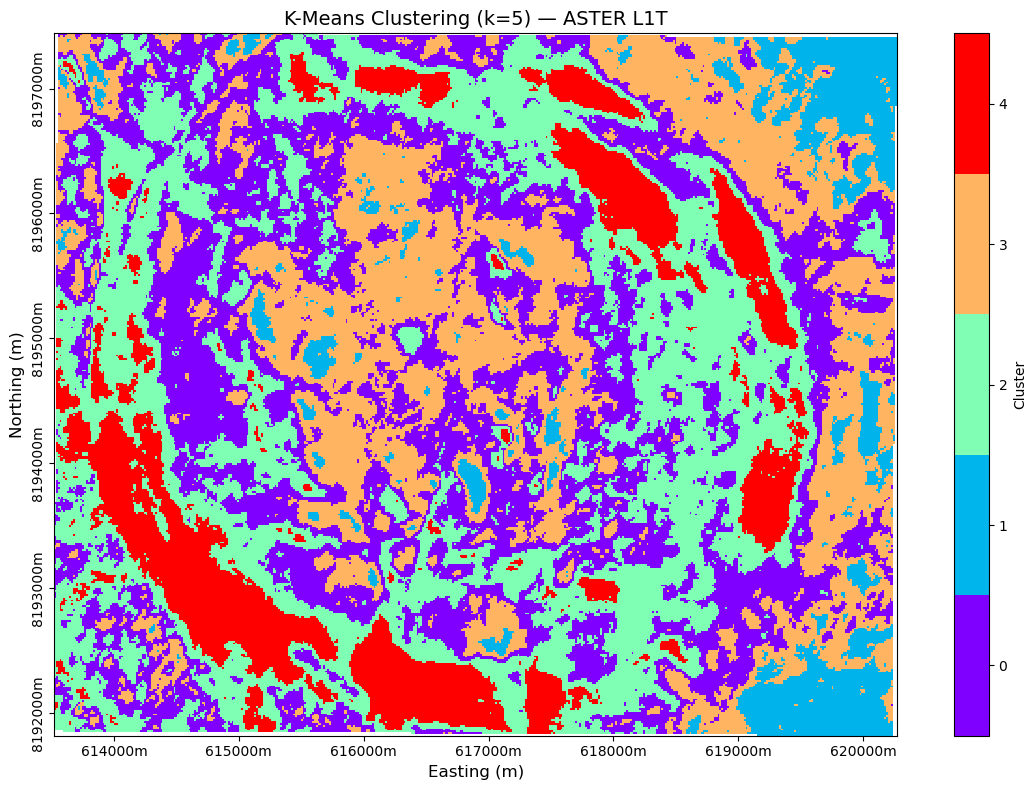

Figure saved → output/aster_kmeans_filtered.png


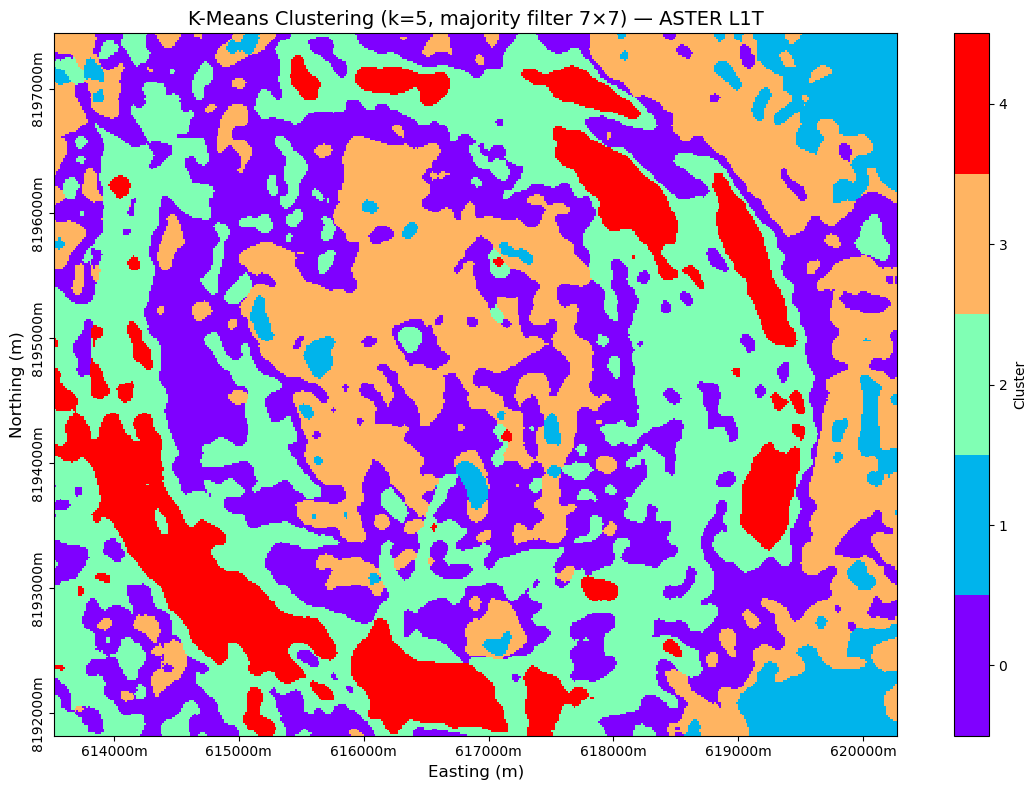

In [18]:
"""
aster_kmeans.py
===============
K-Means clustering on ASTER L1T data after PCA dimensionality reduction.
Adapted from PCA___SOM.ipynb to work with the reprojected/clipped ASTER datacube
produced by aster_preprocess.py.

Key differences from the original Sentinel-2 notebook
------------------------------------------------------
1. ASTER has NaN pixels (NoData + clipped border), so labels must be placed
   back into a spatial array via a valid-pixel mask — the original notebook
   avoided this because Sentinel-2 had no NaN pixels.
2. extent must be derived from the datacube's actual coordinates,
   not from hard-coded WGS84 corners, because after reprojection to
   UTM the x/y axes are in metres.
3. scipy.stats.mode API changed in SciPy ≥ 1.9 — the old
   mode(values)[0][0] idiom now raises a deprecation warning;
   the correct call is mode(values).mode (scalar output).
4. cm.get_cmap is deprecated in matplotlib ≥ 3.7 — use
   matplotlib.colormaps[name] instead.
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.ndimage import generic_filter
from scipy.stats import mode
from sklearn import cluster
from sklearn.decomposition import PCA
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                              silhouette_score, silhouette_samples)
from sklearn.preprocessing import minmax_scale
import rioxarray as rxr

# ---------------------------------------------------------------------------
# 0.  CONFIGURATION
# ---------------------------------------------------------------------------

DATACUBE_PATH  = "output/ASTER_datacube_reproj_clipped.tif"
OUTPUT_DIR     = "output"
N_CLUSTERS     = 5        # override with your elbow result
FILTER_SIZE    = 7        # majority filter kernel (odd number, e.g. 5, 7, 9)
RANDOM_STATE   = 42
VAR_THRESHOLD  = 0.95     # keep enough PCs to explain this fraction of variance

# Silhouette is O(n²) in memory — subsample for speed on large ASTER scenes.
# Set to None to use all valid pixels (exact but slow for > ~50 k pixels).
SILHOUETTE_SAMPLE_SIZE = 10_000

# ---------------------------------------------------------------------------
# 1.  LOAD THE PREPROCESSED DATACUBE
# ---------------------------------------------------------------------------

datacube = rxr.open_rasterio(DATACUBE_PATH, masked=True)   # (Bands, Y, X)
print(f"Datacube shape : {datacube.shape}")
print(f"CRS            : {datacube.rio.crs}")

# Derive the spatial extent in the datacube's own CRS
# (x and y are in metres for UTM, or degrees for EPSG:4326)
min_x = float(datacube.x.min())
max_x = float(datacube.x.max())
min_y = float(datacube.y.min())
max_y = float(datacube.y.max())
extent = [min_x, max_x, min_y, max_y]          # [left, right, bottom, top]
spatial_shape = (datacube.shape[1], datacube.shape[2])   # (Y, X)

print(f"Spatial extent : {extent}")
print(f"Spatial shape  : {spatial_shape}")

# ---------------------------------------------------------------------------
# 2.  BUILD THE FLAT ML ARRAY  (valid pixels only, no NaN)
# ---------------------------------------------------------------------------

data_yxb = np.moveaxis(datacube.values, 0, -1)            # (Y, X, Bands)

# Normalise each band to [0, 1]  (same as minmax_scale in the notebook)
min_vals = np.nanmin(data_yxb, axis=(0, 1), keepdims=True)
max_vals = np.nanmax(data_yxb, axis=(0, 1), keepdims=True)
data_norm = (data_yxb - min_vals) / (max_vals - min_vals + 1e-10)

# Flatten to (total_pixels, n_bands)
n_px = spatial_shape[0] * spatial_shape[1]
data_flat = data_norm.reshape(n_px, -1)

# Valid-pixel mask  — needed to put labels back into a 2-D map later
valid_mask = ~np.isnan(data_flat).any(axis=1)
data_valid = data_flat[valid_mask]
print(f"Valid pixels   : {data_valid.shape[0]} / {n_px} "
      f"({100*data_valid.shape[0]/n_px:.1f} %)")

# ---------------------------------------------------------------------------
# 3.  PCA
# ---------------------------------------------------------------------------

pca = PCA()
components_all = pca.fit_transform(data_valid)

var_ratio = pca.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)
n_keep    = int(np.searchsorted(cumvar, VAR_THRESHOLD)) + 1
selected_components = components_all[:, :n_keep]

print(f"\nPCA — keeping {n_keep} components "
      f"({100*cumvar[n_keep-1]:.1f} % variance explained)")
print(f"Explained variance per component: "
      f"{[round(v, 4) for v in var_ratio[:n_keep]]}")

# ---------------------------------------------------------------------------
# 4.  PER-K METRICS SWEEP  (inertia · silhouette · CH · DB)
# ---------------------------------------------------------------------------
# Silhouette is O(n²) in memory. We subsample once and reuse the same
# subsample across every k so the scores are directly comparable.

rng = np.random.default_rng(RANDOM_STATE)
n_valid = selected_components.shape[0]

if SILHOUETTE_SAMPLE_SIZE is None or SILHOUETTE_SAMPLE_SIZE >= n_valid:
    sil_idx  = np.arange(n_valid)
    sil_data = selected_components
else:
    sil_idx  = rng.choice(n_valid, size=SILHOUETTE_SAMPLE_SIZE, replace=False)
    sil_data = selected_components[sil_idx]

print(f"\nRunning per-k sweep (k=2..20) — silhouette subsample: {len(sil_idx):,} pixels")

range_n_clusters   = range(2, 21)
inertia_scores     = []
silhouette_scores  = []
ch_scores          = []
db_scores          = []

for k in range_n_clusters:
    km = cluster.KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(selected_components)

    inertia_scores.append(km.inertia_)

    # Silhouette on the fixed subsample — labels come from the full fit
    sil_labels = km.labels_[sil_idx]
    # Need at least 2 clusters represented in the subsample
    if len(np.unique(sil_labels)) >= 2:
        silhouette_scores.append(silhouette_score(sil_data, sil_labels))
    else:
        silhouette_scores.append(np.nan)

    ch_scores.append(calinski_harabasz_score(selected_components, km.labels_))
    db_scores.append(davies_bouldin_score(selected_components, km.labels_))

    print(f"  k={k:2d}  inertia={km.inertia_:>12.1f}  "
          f"sil={silhouette_scores[-1]:.4f}  "
          f"CH={ch_scores[-1]:>10.1f}  DB={db_scores[-1]:.4f}")

# ── Three-panel diagnostic figure ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ks = list(range_n_clusters)

# Panel 1 — Elbow (inertia)
ax1 = axes[0]
range_ssd = max(inertia_scores) - min(inertia_scores)
y_lo = min(inertia_scores) - 0.1 * range_ssd
y_hi = max(inertia_scores) + 0.1 * range_ssd
ax1.plot(ks, inertia_scores, 'ko--', mfc='r', label='Inertia')
ax1.axvline(N_CLUSTERS, color='g', linestyle='--', label=f'k={N_CLUSTERS}')
ax1.set_xticks(range(2, 21, 2))
ax1.set_ylim(y_lo, y_hi)
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia (sum of squared distances)')
ax1.set_title('Elbow curve')
ax1.grid(linestyle='--', alpha=0.5)
ax1.legend(fontsize=9)

# Panel 2 — Silhouette score  (higher is better, range −1 to +1)
ax2 = axes[1]
ax2.plot(ks, silhouette_scores, 's--', color='coral',
         mfc='white', mew=2, mec='coral', label='Silhouette')
ax2.axvline(N_CLUSTERS, color='g', linestyle='--', label=f'k={N_CLUSTERS}')
ax2.axhline(0, color='red', linestyle=':', linewidth=1, alpha=0.6, label='Baseline (0)')
ax2.set_xticks(range(2, 21, 2))
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Mean silhouette score')
ax2.set_title('Silhouette score')
ax2.grid(linestyle='--', alpha=0.5)
ax2.legend(fontsize=9)

# Panel 3 — CH (higher = better) on left y-axis, DB (lower = better) on right
ax3 = axes[2]
ax3b = ax3.twinx()
l1, = ax3.plot(ks, ch_scores, '^--', color='steelblue',
               mfc='white', mew=2, label='CH score (↑)')
l2, = ax3b.plot(ks, db_scores, 'D--', color='darkorange',
                mfc='white', mew=2, label='DB score (↓)')
ax3.axvline(N_CLUSTERS, color='g', linestyle='--', label=f'k={N_CLUSTERS}')
ax3.set_xticks(range(2, 21, 2))
ax3.set_xlabel('Number of clusters')
ax3.set_ylabel('Calinski–Harabász score', color='steelblue')
ax3b.set_ylabel('Davies–Bouldin score', color='darkorange')
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3b.tick_params(axis='y', labelcolor='darkorange')
ax3.set_title('CH & DB scores')
ax3.grid(linestyle='--', alpha=0.5)
lines = [l1, l2, ax3.axvline(N_CLUSTERS, color='g', linestyle='--')]
ax3.legend(handles=[l1, l2], fontsize=9, loc='upper right')

fig.suptitle('K-Means cluster-quality diagnostics — ASTER L1T', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aster_kmeans_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Diagnostic plot saved → {OUTPUT_DIR}/aster_kmeans_diagnostics.png")

# ---------------------------------------------------------------------------
# 5.  K-MEANS  (reuse same subsample; re-fit final model for chosen k)
# ---------------------------------------------------------------------------

clusterer    = cluster.KMeans(n_clusters=N_CLUSTERS,
                               random_state=RANDOM_STATE,
                               n_init="auto")
labels_valid = clusterer.fit_predict(selected_components)

ch_score = calinski_harabasz_score(selected_components, labels_valid)
db_score = davies_bouldin_score(selected_components, labels_valid)
sil_mean = silhouette_score(sil_data, labels_valid[sil_idx])

print(f"\n── Final model  k={N_CLUSTERS} ──────────────────────────")
print(f"Calinski-Harabász : {ch_score:.4f}  (higher = better)")
print(f"Davies-Bouldin    : {db_score:.4f}  (lower  = better)")
print(f"Silhouette (mean) : {sil_mean:.4f}  (range −1 to +1, higher = better)")

# ── Per-cluster silhouette bar chart + violin ───────────────────────────────
sil_vals    = silhouette_samples(sil_data, labels_valid[sil_idx])
sil_by_clus = {c: sil_vals[labels_valid[sil_idx] == c] for c in range(N_CLUSTERS)}
cluster_sizes = np.bincount(labels_valid, minlength=N_CLUSTERS)

try:
    cmap_disc = mpl.colormaps['rainbow'].resampled(N_CLUSTERS)
except AttributeError:
    cmap_disc = cm.get_cmap('rainbow', N_CLUSTERS)

colors = [cmap_disc(c / (N_CLUSTERS - 1 or 1)) for c in range(N_CLUSTERS)]
y_pos  = np.arange(N_CLUSTERS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel — mean ± std horizontal bars
ax_bar = axes[0]
means = [sil_by_clus[c].mean() for c in range(N_CLUSTERS)]
stds  = [sil_by_clus[c].std()  for c in range(N_CLUSTERS)]
ax_bar.barh(y_pos, means, xerr=stds, color=colors,
            edgecolor='grey', linewidth=0.6,
            error_kw=dict(ecolor='black', capsize=4, linewidth=1))
ax_bar.axvline(sil_mean, color='black', linestyle='--', linewidth=1.2,
               label=f'Overall mean = {sil_mean:.3f}')
ax_bar.axvline(0, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([f'Cluster {c}  (n={cluster_sizes[c]:,})' for c in range(N_CLUSTERS)],
                        fontsize=9)
ax_bar.set_xlabel('Silhouette coefficient')
ax_bar.set_title(f'Per-cluster mean ± std  (k={N_CLUSTERS})\nsubsample = {len(sil_idx):,} pixels')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='x', linestyle='--', alpha=0.5)
ax_bar.set_xlim(-1, 1)

# Right panel — violin distributions
ax_vio = axes[1]
parts = ax_vio.violinplot(
    [sil_by_clus[c] for c in range(N_CLUSTERS)],
    positions=y_pos, vert=False,
    showmedians=True, showextrema=False,
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('grey')
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)
ax_vio.axvline(sil_mean, color='black', linestyle='--', linewidth=1.2,
               label=f'Overall mean = {sil_mean:.3f}')
ax_vio.axvline(0, color='red', linestyle=':', linewidth=1, alpha=0.7,
               label='Baseline (0)')
ax_vio.set_yticks(y_pos)
ax_vio.set_yticklabels([f'Cluster {c}' for c in range(N_CLUSTERS)], fontsize=9)
ax_vio.set_xlabel('Silhouette coefficient')
ax_vio.set_title(f'Score distribution per cluster  (k={N_CLUSTERS})\nblack tick = median')
ax_vio.legend(fontsize=9)
ax_vio.grid(axis='x', linestyle='--', alpha=0.5)
ax_vio.set_xlim(-1, 1)

fig.suptitle('Silhouette analysis — ASTER L1T K-Means', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aster_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Silhouette plot saved → {OUTPUT_DIR}/aster_kmeans_silhouette.png")

# Compact per-cluster summary table
print(f"\n{'Cluster':>8}  {'n pixels':>10}  {'sil mean':>10}  "
      f"{'sil std':>9}  {'sil min':>9}  {'sil max':>9}")
print("─" * 62)
for c in range(N_CLUSTERS):
    v = sil_by_clus[c]
    print(f"{c:>8}  {cluster_sizes[c]:>10,}  {v.mean():>10.4f}  "
          f"{v.std():>9.4f}  {v.min():>9.4f}  {v.max():>9.4f}")

# ---------------------------------------------------------------------------
# 6.  RECONSTRUCT SPATIAL LABEL MAP  (handles NaN pixels correctly)
# ---------------------------------------------------------------------------

# Fill a full-size flat array with NaN, then place valid labels
labels_full = np.full(n_px, np.nan, dtype=float)
labels_full[valid_mask] = labels_valid

# Reshape to (Y, X)
labels_2d = labels_full.reshape(spatial_shape)
print(f"\nLabel map shape: {labels_2d.shape}")
print(f"Unique clusters: {np.unique(labels_valid)}")

# ---------------------------------------------------------------------------
# 7.  MAJORITY (MODE) FILTER  — smooths speckle noise
#     scipy.stats.mode API: use .mode (not [0][0]) for SciPy >= 1.9
# ---------------------------------------------------------------------------

def filter_function(window_values):
    """
    Majority filter for generic_filter.
    Ignores NaN border pixels so the mask doesn't bleed into valid area.
    """
    valid = window_values[~np.isnan(window_values)]
    if len(valid) == 0:
        return np.nan
    # scipy >= 1.9: mode() returns a scalar directly
    result = mode(valid, keepdims=False)
    return float(result.mode)

labels_major = generic_filter(labels_2d,
                               function=filter_function,
                               size=FILTER_SIZE)
print(f"Majority filter applied (kernel={FILTER_SIZE}×{FILTER_SIZE})")

# ---------------------------------------------------------------------------
# 8.  PLOT
# ---------------------------------------------------------------------------

def plot_map(array, extent, n_clusters, title="K-Means Clustering", save_path=None):
    """
    Render the cluster label map as a colour image.

    Parameters
    ----------
    array      : 2-D numpy array of cluster IDs (NaN = masked)
    extent     : [left, right, bottom, top] in the datacube's CRS
    n_clusters : number of clusters (sets the discrete colormap)
    title      : figure title
    save_path  : if given, saves the figure to this path at 300 dpi
    """
    # matplotlib >= 3.7: cm.get_cmap is deprecated
    try:
        cmap = mpl.colormaps['rainbow'].resampled(n_clusters)
    except AttributeError:
        # fallback for older matplotlib
        cmap = cm.get_cmap('rainbow', n_clusters)

    # Mask NaN so imshow renders them transparent
    array_masked = np.ma.masked_invalid(array)

    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(array_masked,
                   cmap=cmap,
                   vmin=-0.5,
                   vmax=n_clusters - 0.5,
                   extent=extent,
                   origin='upper',
                   interpolation='nearest')

    # Format axis ticks — use decimals for geographic CRS, integers for UTM
    if abs(extent[0]) < 360:          # likely geographic degrees
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f°'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f°'))
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
    else:                              # UTM metres
        ax.xaxis.set_major_formatter(FormatStrFormatter('%dm'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%dm'))
        ax.set_xlabel('Easting (m)', fontsize=12)
        ax.set_ylabel('Northing (m)', fontsize=12)

    plt.yticks(rotation=90, va='center')

    cbar = plt.colorbar(im, ax=ax, label='Cluster')
    tick_locs = np.arange(n_clusters)
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels([str(i) for i in tick_locs])

    ax.set_title(title, fontsize=14)
    ax.grid(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {save_path}")
    plt.show()


# Raw labels
plot_map(labels_2d, extent, N_CLUSTERS,
         title=f"K-Means Clustering (k={N_CLUSTERS}) — ASTER L1T",
         save_path=f"{OUTPUT_DIR}/aster_kmeans_raw.png")

# Majority-filtered labels
plot_map(labels_major, extent, N_CLUSTERS,
         title=f"K-Means Clustering (k={N_CLUSTERS}, majority filter {FILTER_SIZE}×{FILTER_SIZE}) — ASTER L1T",
         save_path=f"{OUTPUT_DIR}/aster_kmeans_filtered.png")

# SOMS

In [1]:
import torch
import numpy as np
import warnings
import matplotlib.pyplot as plt
from typing import Union, Tuple, Optional, Dict, Any


class SOMTabular:
    """
    Self-Organizing Map for fixed-length tabular vectors.

    Key features:
      - Euclidean distance metric
      - Flexible feature scaling: standard, minmax
      - Robust initialization strategies
      - Comprehensive evaluation metrics
      - Early stopping with patience
      - Per-node training tracking

    Parameters
    ----------
    n_features : int
        Number of input features.
    hiddenSize : int | Tuple[int, int]
        Number of nodes 1D, or (rows, cols) for 2D grid.
    learningRate : float, default=0.3
        Initial learning rate.
    neighborhoodSize : float, default=3.0
        Initial neighborhood radius (sigma) in grid units.
    tol : float, default=1e-5
        Tolerance on map delta for early stopping.
    patience : int, default=5
        Epochs with delta < tol before stopping.
    track_per_node : bool, default=True
        Track per-node deltas over epochs.
    init : str, default="data"
        Weight initialization: "data" (from data range) or "uniform01".
    feature_scaling : Optional[str], default=None
        Feature scaling: None, "standard" (z-score), or "minmax" to [0,1].
    random_state : Optional[int], default=None
        Random seed for reproducibility.
    """

    def __init__(
        self,
        n_features: int,
        hiddenSize: Union[int, Tuple[int, int]] = (10, 10),
        learningRate: float = 0.3,
        neighborhoodSize: float = 3.0,
        tol: float = 1e-10,
        patience: int = 5,
        track_per_node: bool = True,
        init: str = "data",
        feature_scaling: Optional[str] = None,
        random_state: Optional[int] = 40,
    ) -> None:
        # Core parameters
        self.n_features = int(n_features)
        self.hiddenSize = (
            [1, int(hiddenSize)] if isinstance(hiddenSize, int) else list(hiddenSize)
        )
        if len(self.hiddenSize) != 2:
            raise ValueError("hiddenSize must be int or (rows, cols) tuple.")
        self.n_nodes = self.hiddenSize[0] * self.hiddenSize[1]

        # Learning parameters
        self.learningRateInitial = float(learningRate)
        self.learningRate = float(learningRate)
        self.neighborhoodSizeInitial = float(neighborhoodSize)
        self.neighborhoodSize = float(neighborhoodSize)

        # Convergence parameters
        self.tol = float(tol)
        self.patience = int(patience)
        self.track_per_node = bool(track_per_node)

        # Initialization method validation
        self.init = init.lower()
        if self.init not in {"data", "uniform01"}:
            raise ValueError("init must be 'data' or 'uniform01'")

        # Feature scaling validation
        self.feature_scaling = feature_scaling
        if self.feature_scaling not in {None, "standard", "minmax"}:
            raise ValueError("feature_scaling must be None, 'standard', or 'minmax'")

        # Random state
        if random_state is not None:
            torch.manual_seed(random_state)
            np.random.seed(random_state)

        # Initialize weights: (n_nodes, n_features)
        self.weights_Kohonen = torch.rand(
            self.n_nodes, self.n_features, dtype=torch.float32
        )

        # Grid coordinates for neighborhood calculations
        self.grid = torch.stack(
            torch.meshgrid(
                torch.arange(self.hiddenSize[0]),
                torch.arange(self.hiddenSize[1]),
                indexing="ij",
            ),
            dim=-1,
        ).view(-1, 2)  # (n_nodes, 2)

        # Training history
        self.delta_history = []
        self.node_delta_history = [] if self.track_per_node else None
        self.lr_history = []
        self.sigma_history = []
        self.quantization_error_history = []

        # Winner matrix tracking (hit counts per node)
        self.winner_counts = np.zeros(self.n_nodes, dtype=int)
        
        # Store initial weights for comparison
        self.initial_weights = None

        # Feature scaling parameters
        self._scaler_: Optional[Tuple[torch.Tensor, torch.Tensor]] = None
        self._is_fitted = False

    def _fit_scaler(self, X: torch.Tensor) -> None:
        """Fit feature scaling parameters."""
        if self.feature_scaling == "standard":
            mean = X.mean(dim=0)
            std = X.std(dim=0, unbiased=False).clamp_min(1e-8)
            self._scaler_ = (mean, std)
        elif self.feature_scaling == "minmax":
            xmin, _ = X.min(dim=0)
            xmax, _ = X.max(dim=0)
            scale = (xmax - xmin).clamp_min(1e-8)
            self._scaler_ = (xmin, scale)
        else:
            self._scaler_ = None

    def _transform(self, X: torch.Tensor) -> torch.Tensor:
        """Apply feature scaling transformation."""
        if self._scaler_ is None:
            return X
        
        a, b = self._scaler_
        if self.feature_scaling == "standard":
            return (X - a) / b
        elif self.feature_scaling == "minmax":
            return (X - a) / b
        return X

    def _inverse_transform(self, X: torch.Tensor) -> torch.Tensor:
        """Inverse feature scaling transformation."""
        if self._scaler_ is None:
            return X
        
        a, b = self._scaler_
        if self.feature_scaling == "standard":
            return X * b + a
        elif self.feature_scaling == "minmax":
            return X * b + a
        return X

    def _pairwise_distances(self, X: torch.Tensor, W: torch.Tensor) -> torch.Tensor:
        """
        Compute pairwise Euclidean distances between samples and weights.
        
        Parameters
        ----------
        X : torch.Tensor, shape (N, n_features)
            Input samples
        W : torch.Tensor, shape (M, n_features)
            Weight vectors
            
        Returns
        -------
        torch.Tensor, shape (N, M)
            Pairwise distance matrix
        """
        diff = X[:, None, :] - W[None, :, :]  # (N, M, F)
        return torch.norm(diff, dim=2)

    def find_neighbor_indices(
        self, j: Union[int, torch.Tensor], return_weights: bool = False
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Find neighboring nodes within the current neighborhood radius.
        
        Parameters
        ----------
        j : int or torch.Tensor
            Index of the BMU
        return_weights : bool, default=False
            Whether to return Gaussian weights
            
        Returns
        -------
        torch.Tensor or Tuple[torch.Tensor, torch.Tensor]
            Neighbor indices, optionally with weights
        """
        if isinstance(j, torch.Tensor):
            j = int(j.item())
        
        r_bmu, c_bmu = np.unravel_index(j, self.hiddenSize)
        indices = []
        distances = []
        
        # Find all nodes within neighborhood radius
        for i in range(self.n_nodes):
            r, c = np.unravel_index(i, self.hiddenSize)
            dist = np.sqrt((r - r_bmu) ** 2 + (c - c_bmu) ** 2)
            if dist <= self.neighborhoodSize:
                indices.append(i)
                distances.append(dist)
        
        indices_tensor = torch.tensor(indices, dtype=torch.long)
        
        if not return_weights:
            return indices_tensor
        
        # Compute Gaussian weights
        distances_tensor = torch.tensor(distances, dtype=torch.float32)
        sigma = max(self.neighborhoodSize, 1e-6)
        weights = torch.exp(-(distances_tensor ** 2) / (2.0 * sigma ** 2))
        
        return indices_tensor, weights

    def are_neighbors(self, idx1: int, idx2: int) -> bool:
        """Check if two nodes are neighbors within current radius."""
        r1, c1 = np.unravel_index(idx1, self.hiddenSize)
        r2, c2 = np.unravel_index(idx2, self.hiddenSize)
        dist = np.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)
        return dist <= self.neighborhoodSize

    def compute_bmu(self, x: torch.Tensor) -> Tuple[int, float]:
        """
        Find Best Matching Unit (BMU) for a single sample.
        
        Parameters
        ----------
        x : torch.Tensor, shape (n_features,)
            Input sample
            
        Returns
        -------
        Tuple[int, float]
            BMU index and distance
        """
        x = x.view(1, -1)
        distances = self._pairwise_distances(x, self.weights_Kohonen).view(-1)
        idx = int(torch.argmin(distances).item())
        return idx, float(distances[idx].item())

    def propagate_forward(
        self, inputs: Union[np.ndarray, torch.Tensor]
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Find BMUs for all input samples.
        
        Parameters
        ----------
        inputs : array-like, shape (n_samples, n_features)
            Input data
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            BMU indices and distances for each sample
        """
        if isinstance(inputs, np.ndarray):
            inputs = torch.from_numpy(inputs).float()
        X = inputs
        
        distance_matrix = self._pairwise_distances(X, self.weights_Kohonen)  # (N, M)
        distances, indices = torch.min(distance_matrix, dim=1)
        
        return indices, distances

    def _init_weights(self, X: torch.Tensor) -> None:
        """Initialize SOM weights based on data or uniform distribution."""
        if self.init == "uniform01":
            self.weights_Kohonen.uniform_(0.0, 1.0)
        elif self.init == "data":
            # Initialize within data range using min-max values
            x_min, _ = X.min(dim=0)
            x_max, _ = X.max(dim=0)
            for f in range(self.n_features):
                self.weights_Kohonen[:, f].uniform_(
                    float(x_min[f].item()), float(x_max[f].item())
                )

    def update_weights_Kohonen(self, x: torch.Tensor, bmu_index: int) -> None:
        """
        Update SOM weights using competitive learning rule.
        
        Parameters
        ----------
        x : torch.Tensor, shape (n_features,)
            Input sample
        bmu_index : int
            Index of the best matching unit
        """
        x = x.view(1, -1)
        
        # Find neighbors and their weights
        neighbors, gaussian_weights = self.find_neighbor_indices(
            bmu_index, return_weights=True
        )
        
        # Vectorized weight update
        difference = x - self.weights_Kohonen[neighbors]  # (k, n_features)
        update = (
            self.learningRate * gaussian_weights[:, None] * difference
        )  # (k, n_features)
        self.weights_Kohonen[neighbors] += update

    def quantization_error(self, data: Union[np.ndarray, torch.Tensor]) -> float:
        """
        Compute quantization error (average distance to BMU).

        Parameters
        ----------
        data : array-like, shape (n_samples, n_features)
            Input data
            
        Returns
        -------
        float
            Average quantization error
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before computing quantization error")
        
        if isinstance(data, np.ndarray):
            data = torch.from_numpy(data).float()
        X = data
        X_scaled = self._transform(X)
        
        _, distances = self.propagate_forward(X_scaled)
        return float(distances.mean().item())

    def iterate(
        self,
        inputs: Union[np.ndarray, torch.Tensor],
        epochs: int = 50,
        randomInitialization: bool = True,
        decay_rate: float = 0.01,
        shuffle: bool = True,
        verbose: bool = True,
    ) -> Dict[str, Any]:
        """
        Train the SOM using stochastic gradient descent with exponential decay.
        
        Parameters
        ----------
        inputs : array-like, shape (n_samples, n_features)
            Training data
        epochs : int, default=50
            Maximum number of training epochs
        randomInitialization : bool, default=True
            Whether to randomly initialize weights
        decay_rate : float, default=0.01
            Exponential decay rate for learning rate and neighborhood size
        shuffle : bool, default=True
            Whether to shuffle samples each epoch
        verbose : bool, default=True
            Whether to print convergence information
            
        Returns
        -------
        Dict[str, Any]
            Training history and final metrics
        """
        # Prepare input data - ensure it's a PyTorch tensor
        if isinstance(inputs, np.ndarray):
            X = torch.from_numpy(inputs).float()
        elif isinstance(inputs, torch.Tensor):
            X = inputs.float()
        else:
            # Try to convert other types (like pandas DataFrame)
            X = torch.from_numpy(np.array(inputs)).float()
        
        # Fit and apply feature scaling
        self._fit_scaler(X)
        X_scaled = self._transform(X)
        
        # Initialize weights
        if randomInitialization:
            self._init_weights(X_scaled)
        
        # Store initial weights for later comparison
        self.initial_weights = self.weights_Kohonen.clone().detach()
        
        # Reset training state
        self.learningRate = self.learningRateInitial
        self.neighborhoodSize = self.neighborhoodSizeInitial
        self.delta_history = []
        self.lr_history = []
        self.sigma_history = []
        self.quantization_error_history = []
        self.winner_counts = np.zeros(self.n_nodes, dtype=int)
        if self.track_per_node:
            self.node_delta_history = []
        
        prev_weights = self.weights_Kohonen.clone()
        stagnant_epochs = 0
        
        for epoch in range(epochs):
            # Optional shuffling
            if shuffle:
                perm = torch.randperm(X_scaled.size(0))
                X_epoch = X_scaled[perm]
            else:
                X_epoch = X_scaled
            
            # SGD updates
            for x in X_epoch:
                bmu_idx, _ = self.compute_bmu(x)
                self.update_weights_Kohonen(x, bmu_idx)
                # Track winner counts
                self.winner_counts[bmu_idx] += 1
            
            # Exponential decay
            self.learningRate = self.learningRateInitial * np.exp(-decay_rate * epoch)
            self.neighborhoodSize = max(
                0.1, self.neighborhoodSizeInitial * np.exp(-decay_rate * epoch)
            )
            
            # Track training progress
            delta = torch.norm(self.weights_Kohonen - prev_weights).item()
            self.delta_history.append(delta)
            self.lr_history.append(self.learningRate)
            self.sigma_history.append(self.neighborhoodSize)
            
            if self.track_per_node:
                node_deltas = torch.norm(self.weights_Kohonen - prev_weights, dim=1)
                self.node_delta_history.append(node_deltas.detach().cpu().numpy())
            
            # Early stopping check
            if delta < self.tol:
                stagnant_epochs += 1
                if stagnant_epochs >= self.patience:
                    if verbose:
                        print(f"SOM converged at epoch {epoch + 1} (Δ={delta:.2e})")
                    break
            else:
                stagnant_epochs = 0
            
            prev_weights = self.weights_Kohonen.clone()
            
            # Progress reporting
            if verbose and (epoch + 1) % max(1, epochs // 10) == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs}: Δ={delta:.2e}, "
                    f"LR={self.learningRate:.4f}, σ={self.neighborhoodSize:.2f}"
                )
        
        self._is_fitted = True
        
        # Return training summary
        return {
            "epochs_run": epoch + 1,
            "converged": stagnant_epochs >= self.patience,
            "final_delta": delta,
            "final_lr": self.learningRate,
            "final_sigma": self.neighborhoodSize,
            "quantization_error_history": self.quantization_error_history,
        }

    def mean_pairwise_distance(self, data: Union[np.ndarray, torch.Tensor]) -> float:
        """
        Compute mean pairwise distance between all samples.
        
        Parameters
        ----------
        data : array-like, shape (n_samples, n_features)
            Input data
            
        Returns
        -------
        float
            Mean pairwise distance
        """
        if isinstance(data, np.ndarray):
            data = torch.from_numpy(data).float()
        X = data
        X_scaled = self._transform(X)
        
        N = X_scaled.size(0)
        if N < 2:
            return 0.0
        
        # Use broadcasting for efficient computation
        diff = X_scaled[:, None, :] - X_scaled[None, :, :]  # (N, N, F)
        distances = torch.norm(diff, dim=2)  # (N, N)
        
        # Extract upper triangle (avoid double counting and diagonal)
        mask = torch.triu(torch.ones(N, N), diagonal=1).bool()
        return float(distances[mask].mean().item())

    def predict(self, inputs: Union[np.ndarray, torch.Tensor]) -> np.ndarray:
        """
        Predict BMU indices for input samples.
        
        Parameters
        ----------
        inputs : array-like, shape (n_samples, n_features)
            Input data
            
        Returns
        -------
        np.ndarray, shape (n_samples,)
            BMU indices for each input sample
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before making predictions")
        
        if isinstance(inputs, np.ndarray):
            inputs = torch.from_numpy(inputs).float()
        X = inputs
        X_scaled = self._transform(X)
        
        bmu_indices, _ = self.propagate_forward(X_scaled)
        return bmu_indices.detach().cpu().numpy()

    def transform(self, inputs: Union[np.ndarray, torch.Tensor]) -> np.ndarray:
        """
        Transform input data to SOM coordinate space.
        
        Parameters
        ----------
        inputs : array-like, shape (n_samples, n_features)
            Input data
            
        Returns
        -------
        np.ndarray, shape (n_samples, 2)
            2D coordinates in SOM grid space
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before transforming data")
        
        bmu_indices = self.predict(inputs)
        coordinates = np.array(
            [np.unravel_index(idx, self.hiddenSize) for idx in bmu_indices]
        )
        return coordinates

    def u_matrix(self) -> np.ndarray:
        """
        Compute the U-matrix (unified distance matrix) showing average distances 
        between each node and its immediate neighbors.
        
        Returns
        -------
        np.ndarray, shape hiddenSize
            U-matrix values for visualization
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before computing U-matrix")
        
        W = self.weights_Kohonen.detach().cpu()
        rows, cols = self.hiddenSize
        U = torch.zeros(self.n_nodes)
        
        for idx in range(self.n_nodes):
            r, c = np.unravel_index(idx, self.hiddenSize)
            
            # Find immediate neighbors (8-connectivity)
            neighbors = []
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < rows and 0 <= nc < cols:
                        neighbors.append(nr * cols + nc)
            
            if neighbors:
                # Compute average distance to neighbors
                neighbor_weights = W[neighbors]  # (k, n_features)
                distances = torch.norm(W[idx] - neighbor_weights, dim=1)
                U[idx] = distances.mean()
        
        return U.view(rows, cols).numpy()

    def get_distance_matrix(self) -> np.ndarray:
        """
        Alias for u_matrix() for consistency with visualization methods.
        
        Returns
        -------
        np.ndarray, shape hiddenSize
            Distance matrix (U-matrix) values
        """
        return self.u_matrix()

    def get_winner_matrix(self) -> np.ndarray:
        """
        Get the winner matrix showing hit counts for each node.
        
        Returns
        -------
        np.ndarray, shape hiddenSize
            Number of times each node was the BMU during training
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before getting winner matrix")
        
        return self.winner_counts.reshape(self.hiddenSize)

    def get_weight_change_matrix(self) -> np.ndarray:
        """
        Compute how much each node's weights changed during training.
        
        Returns
        -------
        np.ndarray, shape hiddenSize
            Magnitude of weight change for each node
        """
        if not self._is_fitted or self.initial_weights is None:
            raise ValueError("SOM must be fitted to compute weight changes")
        
        weight_deltas = torch.norm(
            self.weights_Kohonen - self.initial_weights, dim=1
        )
        return weight_deltas.detach().cpu().numpy().reshape(self.hiddenSize)

    def show_distance_matrix(self, figsize: Tuple[int, int] = (8, 6)) -> None:
        """
        Visualize the U-matrix (distance matrix).
        
        Parameters
        ----------
        figsize : Tuple[int, int], default=(8, 6)
            Figure size for the plot
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before visualization")
        
        fig, ax = plt.subplots(figsize=figsize)
        distance_matrix = self.get_distance_matrix()
        
        im = ax.imshow(distance_matrix.T, cmap='inferno_r', interpolation='kaiser')
        ax.set_title('U-Matrix (Distance Matrix)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        plt.colorbar(im, ax=ax, label='Average Distance to Neighbors')
        plt.tight_layout()
        plt.show()

    def show_winner_matrix(self, figsize: Tuple[int, int] = (8, 6), 
                          show_counts: bool = True) -> None:
        """
        Visualize the winner matrix (hit counts).
        
        Parameters
        ----------
        figsize : Tuple[int, int], default=(8, 6)
            Figure size for the plot
        show_counts : bool, default=True
            Whether to show numerical counts on each cell
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before visualization")
        
        fig, ax = plt.subplots(figsize=figsize)
        winner_matrix = self.get_winner_matrix()
        
        im = ax.imshow(winner_matrix.T, cmap='cool', interpolation='none')
        ax.set_title('Winner Matrix (Hit Counts)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
        
        if show_counts:
            for i in range(winner_matrix.shape[0]):
                for j in range(winner_matrix.shape[1]):
                    ax.text(i, j, str(int(winner_matrix[i, j])),
                           va='center', ha='center', 
                           color='white' if winner_matrix[i, j] > winner_matrix.max()/2 else 'black',
                           fontsize=8, fontweight='bold')
        
        plt.colorbar(im, ax=ax, label='Number of Hits')
        plt.tight_layout()
        plt.show()

    def show_weight_change_matrix(self, figsize: Tuple[int, int] = (8, 6)) -> None:
        """
        Visualize how much each node's weights changed during training.
        
        Parameters
        ----------
        figsize : Tuple[int, int], default=(8, 6)
            Figure size for the plot
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before visualization")
        
        fig, ax = plt.subplots(figsize=figsize)
        weight_change_matrix = self.get_weight_change_matrix()
        
        im = ax.imshow(weight_change_matrix.T, cmap='viridis', interpolation='kaiser')
        ax.set_title('Weight Change Matrix', fontsize=12, fontweight='bold')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        plt.colorbar(im, ax=ax, label='Weight Change Magnitude')
        plt.tight_layout()
        plt.show()

    def show_som_analysis(self, figsize: Tuple[int, int] = (16, 10)) -> None:
        """
        Show comprehensive SOM analysis with multiple visualizations.
        
        Parameters
        ----------
        figsize : Tuple[int, int], default=(16, 10)
            Figure size for the entire plot
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before visualization")
        
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
        
        # 1. Distance Matrix (U-Matrix)
        ax1 = fig.add_subplot(gs[0, 0])
        distance_matrix = self.get_distance_matrix()
        im1 = ax1.imshow(distance_matrix.T, cmap='inferno_r', interpolation='kaiser')
        ax1.set_title('U-Matrix (Distance Matrix)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Column')
        ax1.set_ylabel('Row')
        plt.colorbar(im1, ax=ax1, label='Avg Distance')
        
        # 2. Winner Matrix
        ax2 = fig.add_subplot(gs[0, 1])
        winner_matrix = self.get_winner_matrix()
        im2 = ax2.imshow(winner_matrix.T, cmap='cool', interpolation='none')
        ax2.set_title('Winner Matrix (Hit Counts)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Row')
        ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
        for i in range(winner_matrix.shape[0]):
            for j in range(winner_matrix.shape[1]):
                count = int(winner_matrix[i, j])
                color = 'white' if count > winner_matrix.max()/2 else 'black'
                ax2.text(i, j, str(count), va='center', ha='center',
                        color=color, fontsize=8, fontweight='bold')
        plt.colorbar(im2, ax=ax2, label='Hits')
        
        # 3. Weight Change Matrix
        ax3 = fig.add_subplot(gs[0, 2])
        weight_change_matrix = self.get_weight_change_matrix()
        im3 = ax3.imshow(weight_change_matrix.T, cmap='viridis', interpolation='kaiser')
        ax3.set_title('Weight Change Matrix', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Column')
        ax3.set_ylabel('Row')
        plt.colorbar(im3, ax=ax3, label='Change Magnitude')
        
        # 4. Training Delta History
        ax4 = fig.add_subplot(gs[1, 0])
        ax4.plot(self.delta_history, linewidth=2)
        ax4.set_title('Weight Delta History', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Delta')
        ax4.set_yscale('log')
        ax4.grid(True, alpha=0.3)
        
        # 5. Learning Rate and Neighborhood Size
        ax5 = fig.add_subplot(gs[1, 1])
        ax5_twin = ax5.twinx()
        line1 = ax5.plot(self.lr_history, 'b-', linewidth=2, label='Learning Rate')
        line2 = ax5_twin.plot(self.sigma_history, 'r-', linewidth=2, label='Neighborhood Size')
        ax5.set_title('Training Parameters', fontsize=12, fontweight='bold')
        ax5.set_xlabel('Epoch')
        ax5.set_ylabel('Learning Rate', color='b')
        ax5_twin.set_ylabel('Neighborhood Size (σ)', color='r')
        ax5.tick_params(axis='y', labelcolor='b')
        ax5_twin.tick_params(axis='y', labelcolor='r')
        ax5.grid(True, alpha=0.3)
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax5.legend(lines, labels, loc='upper right')
        
        # 6. Node Utilization Statistics
        ax6 = fig.add_subplot(gs[1, 2])
        unique_winners = np.sum(winner_matrix > 0)
        utilization = unique_winners / self.n_nodes * 100
        
        stats_text = f"""
        Total Nodes: {self.n_nodes}
        Active Nodes: {unique_winners}
        Utilization: {utilization:.1f}%
        
        Hit Statistics:
        Max Hits: {int(winner_matrix.max())}
        Min Hits: {int(winner_matrix.min())}
        Mean Hits: {winner_matrix.mean():.1f}
        Std Hits: {winner_matrix.std():.1f}
        
        Weight Changes:
        Max Change: {weight_change_matrix.max():.3f}
        Min Change: {weight_change_matrix.min():.3f}
        Mean Change: {weight_change_matrix.mean():.3f}
        """
        
        ax6.text(0.1, 0.5, stats_text, transform=ax6.transAxes,
                fontsize=10, verticalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        ax6.axis('off')
        ax6.set_title('SOM Statistics', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()

    def show_weight_mesh(self, feature_indices: Tuple[int, int] = (1, 0),
                        figsize: Tuple[int, int] = (16, 6),
                        show_nodes: bool = True,
                        show_connections: bool = True) -> None:
        """
        Visualize the spatial organization of SOM nodes in feature space.
        Shows both initial and final weight positions as a mesh/network.
        
        Parameters
        ----------
        feature_indices : Tuple[int, int], default=(0, 1)
            Which two features to plot (for 2D visualization)
        figsize : Tuple[int, int], default=(16, 6)
            Figure size for the plot
        show_nodes : bool, default=True
            Whether to show node markers
        show_connections : bool, default=True
            Whether to show connections between neighboring nodes
        """
        if not self._is_fitted or self.initial_weights is None:
            raise ValueError("SOM must be fitted to visualize weight mesh")
        
        if self.n_features < 2:
            raise ValueError("Need at least 2 features for mesh visualization")
        
        feat_x, feat_y = feature_indices
        if feat_x >= self.n_features or feat_y >= self.n_features:
            raise ValueError(f"Feature indices must be < {self.n_features}")
        
        # Get weights (transform back to original space if scaled)
        initial_weights = self.initial_weights.detach().cpu()
        final_weights = self.weights_Kohonen.detach().cpu()
        
        if self._scaler_ is not None:
            initial_weights = self._inverse_transform(initial_weights)
            final_weights = self._inverse_transform(final_weights)
        
        initial_weights = initial_weights.numpy()
        final_weights = final_weights.numpy()
        
        rows, cols = self.hiddenSize
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Plot initial mesh
        self._plot_weight_mesh_single(
            ax1, initial_weights, feat_x, feat_y, rows, cols,
            'Initial Weight Mesh (Before Training)',
            show_nodes, show_connections, color='blue'
        )
        
        # Plot final mesh
        self._plot_weight_mesh_single(
            ax2, final_weights, feat_x, feat_y, rows, cols,
            'Final Weight Mesh (After Training)',
            show_nodes, show_connections, color='red'
        )
        
        plt.tight_layout()
        plt.show()

    def _plot_weight_mesh_single(self, ax, weights: np.ndarray,
                                 feat_x: int, feat_y: int,
                                 rows: int, cols: int,
                                 title: str,
                                 show_nodes: bool,
                                 show_connections: bool,
                                 color: str) -> None:
        """
        Helper method to plot a single weight mesh.
        
        Parameters
        ----------
        ax : matplotlib.axes.Axes
            Axes to plot on
        weights : np.ndarray
            Weight matrix (n_nodes, n_features)
        feat_x, feat_y : int
            Feature indices for x and y axes
        rows, cols : int
            Grid dimensions
        title : str
            Plot title
        show_nodes : bool
            Whether to show node markers
        show_connections : bool
            Whether to show connections
        color : str
            Color for the mesh
        """
        # Reshape weights to grid
        weight_grid = weights.reshape(rows, cols, -1)
        
        # Draw connections between neighbors
        if show_connections:
            # Horizontal connections
            for i in range(rows):
                for j in range(cols - 1):
                    x_coords = [weight_grid[i, j, feat_x], weight_grid[i, j + 1, feat_x]]
                    y_coords = [weight_grid[i, j, feat_y], weight_grid[i, j + 1, feat_y]]
                    ax.plot(x_coords, y_coords, color=color, alpha=0.4, linewidth=1)
            
            # Vertical connections
            for i in range(rows - 1):
                for j in range(cols):
                    x_coords = [weight_grid[i, j, feat_x], weight_grid[i + 1, j, feat_x]]
                    y_coords = [weight_grid[i, j, feat_y], weight_grid[i + 1, j, feat_y]]
                    ax.plot(x_coords, y_coords, color=color, alpha=0.4, linewidth=1)
        
        # Draw nodes
        if show_nodes:
            all_x = weight_grid[:, :, feat_x].flatten()
            all_y = weight_grid[:, :, feat_y].flatten()
            ax.scatter(all_x, all_y, c=color, s=50, alpha=0.7, 
                      edgecolors='black', linewidth=0.5, zorder=5)
            
            # Optionally label corner nodes
            ax.scatter(weight_grid[0, 0, feat_x], weight_grid[0, 0, feat_y],
                      c='green', s=100, marker='s', edgecolors='black',
                      linewidth=2, zorder=10, label='Top-left corner')
            ax.scatter(weight_grid[-1, -1, feat_x], weight_grid[-1, -1, feat_y],
                      c='orange', s=100, marker='s', edgecolors='black',
                      linewidth=2, zorder=10, label='Bottom-right corner')
        
        ax.set_xlabel(f'Feature {feat_x}', fontsize=10)
        ax.set_ylabel(f'Feature {feat_y}', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
        ax.set_aspect('equal', adjustable='datalim')

    def show_weight_mesh_overlay(self, feature_indices: Tuple[int, int] = (1, 0),
                                figsize: Tuple[int, int] = (10, 8),
                                show_arrows: bool = True) -> None:
        """
        Overlay initial and final weight meshes to show movement of nodes.
        
        Parameters
        ----------
        feature_indices : Tuple[int, int], default=(0, 1)
            Which two features to plot
        figsize : Tuple[int, int], default=(10, 8)
            Figure size
        show_arrows : bool, default=True
            Whether to show arrows indicating node movement
        """
        if not self._is_fitted or self.initial_weights is None:
            raise ValueError("SOM must be fitted to visualize weight mesh")
        
        if self.n_features < 2:
            raise ValueError("Need at least 2 features for mesh visualization")
        
        feat_x, feat_y = feature_indices
        
        # Get weights
        initial_weights = self.initial_weights.detach().cpu()
        final_weights = self.weights_Kohonen.detach().cpu()
        
        if self._scaler_ is not None:
            initial_weights = self._inverse_transform(initial_weights)
            final_weights = self._inverse_transform(final_weights)
        
        initial_weights = initial_weights.numpy()
        final_weights = final_weights.numpy()
        
        rows, cols = self.hiddenSize
        
        fig, ax = plt.subplots(figsize=figsize)
        
        # Plot both meshes
        self._plot_weight_mesh_single(
            ax, initial_weights, feat_x, feat_y, rows, cols,
            'Weight Mesh Evolution (Blue: Initial → Red: Final)',
            show_nodes=True, show_connections=True, color='blue'
        )
        
        # Overlay final mesh
        weight_grid_final = final_weights.reshape(rows, cols, -1)
        
        # Draw final connections
        for i in range(rows):
            for j in range(cols - 1):
                x_coords = [weight_grid_final[i, j, feat_x], weight_grid_final[i, j + 1, feat_x]]
                y_coords = [weight_grid_final[i, j, feat_y], weight_grid_final[i, j + 1, feat_y]]
                ax.plot(x_coords, y_coords, color='red', alpha=0.4, linewidth=1)
        
        for i in range(rows - 1):
            for j in range(cols):
                x_coords = [weight_grid_final[i, j, feat_x], weight_grid_final[i + 1, j, feat_x]]
                y_coords = [weight_grid_final[i, j, feat_y], weight_grid_final[i + 1, j, feat_y]]
                ax.plot(x_coords, y_coords, color='red', alpha=0.4, linewidth=1)
        
        # Draw final nodes
        all_x_final = weight_grid_final[:, :, feat_x].flatten()
        all_y_final = weight_grid_final[:, :, feat_y].flatten()
        ax.scatter(all_x_final, all_y_final, c='red', s=50, alpha=0.7,
                  edgecolors='black', linewidth=0.5, zorder=5)
        
        # Draw arrows showing movement
        if show_arrows:
            all_x_initial = initial_weights[:, feat_x]
            all_y_initial = initial_weights[:, feat_y]
            
            for i in range(self.n_nodes):
                dx = all_x_final[i] - all_x_initial[i]
                dy = all_y_final[i] - all_y_initial[i]
                
                # Only draw arrow if movement is significant
                movement = np.sqrt(dx**2 + dy**2)
                if movement > 0.01:  # Threshold to avoid clutter
                    ax.arrow(all_x_initial[i], all_y_initial[i], dx, dy,
                           head_width=0.02, head_length=0.02,
                           fc='green', ec='green', alpha=0.3, linewidth=0.5)
        
        plt.tight_layout()
        plt.show()

    def show_weight_mesh_3d(self, figsize: Tuple[int, int] = (16, 6)) -> None:
        """
        Visualize weight mesh in 3D (for n_features >= 3).
        Shows initial and final positions of nodes in 3D feature space.
        
        Parameters
        ----------
        figsize : Tuple[int, int], default=(16, 6)
            Figure size
        """
        if not self._is_fitted or self.initial_weights is None:
            raise ValueError("SOM must be fitted to visualize weight mesh")
        
        if self.n_features < 3:
            raise ValueError("Need at least 3 features for 3D mesh visualization")
        
        from mpl_toolkits.mplot3d import Axes3D
        
        # Get weights
        initial_weights = self.initial_weights.detach().cpu()
        final_weights = self.weights_Kohonen.detach().cpu()
        
        if self._scaler_ is not None:
            initial_weights = self._inverse_transform(initial_weights)
            final_weights = self._inverse_transform(final_weights)
        
        initial_weights = initial_weights.numpy()
        final_weights = final_weights.numpy()
        
        rows, cols = self.hiddenSize
        
        fig = plt.figure(figsize=figsize)
        
        # Initial mesh
        ax1 = fig.add_subplot(121, projection='3d')
        self._plot_weight_mesh_3d_single(ax1, initial_weights, rows, cols,
                                        'Initial Weight Mesh', 'blue')
        
        # Final mesh
        ax2 = fig.add_subplot(122, projection='3d')
        self._plot_weight_mesh_3d_single(ax2, final_weights, rows, cols,
                                        'Final Weight Mesh', 'red')
        
        plt.tight_layout()
        plt.show()

    def _plot_weight_mesh_3d_single(self, ax, weights: np.ndarray,
                                   rows: int, cols: int,
                                   title: str, color: str) -> None:
        """Helper to plot 3D weight mesh."""
        weight_grid = weights.reshape(rows, cols, -1)
        
        # Use first 3 features
        x = weight_grid[:, :, 0].flatten()
        y = weight_grid[:, :, 1].flatten()
        z = weight_grid[:, :, 2].flatten()
        
        # Draw connections
        for i in range(rows):
            for j in range(cols - 1):
                ax.plot([weight_grid[i, j, 0], weight_grid[i, j + 1, 0]],
                       [weight_grid[i, j, 1], weight_grid[i, j + 1, 1]],
                       [weight_grid[i, j, 2], weight_grid[i, j + 1, 2]],
                       color=color, alpha=0.4, linewidth=1)
        
        for i in range(rows - 1):
            for j in range(cols):
                ax.plot([weight_grid[i, j, 0], weight_grid[i + 1, j, 0]],
                       [weight_grid[i, j, 1], weight_grid[i + 1, j, 1]],
                       [weight_grid[i, j, 2], weight_grid[i + 1, j, 2]],
                       color=color, alpha=0.4, linewidth=1)
        
        # Draw nodes
        ax.scatter(x, y, z, c=color, s=50, alpha=0.7,
                  edgecolors='black', linewidth=0.5)
        
        ax.set_xlabel('Feature 0')
        ax.set_ylabel('Feature 1')
        ax.set_zlabel('Feature 2')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)

    def get_node_weights(self) -> np.ndarray:
        """
        Get the current SOM node weights.
        
        Returns
        -------
        np.ndarray, shape (n_nodes, n_features)
            Current weight vectors for all nodes
        """
        weights = self.weights_Kohonen.detach().cpu().numpy()
        if self._scaler_ is not None:
            # Transform back to original space
            weights_tensor = torch.from_numpy(weights)
            weights = self._inverse_transform(weights_tensor).numpy()
        return weights

    def get_grid_coordinates(self) -> np.ndarray:
        """
        Get 2D grid coordinates for all nodes.
        
        Returns
        -------
        np.ndarray, shape (n_nodes, 2)
            Grid coordinates [row, col] for each node
        """
        return self.grid.detach().cpu().numpy()

    def save_results(
        self,
        filename_prefix: str,
        inputs: Optional[Union[np.ndarray, torch.Tensor]] = None,
        save_weights: bool = True,
        save_history: bool = True,
        save_predictions: bool = True,
    ) -> None:
        """
        Save SOM results to files.
        
        Parameters
        ----------
        filename_prefix : str
            Prefix for output filenames
        inputs : array-like, optional
            Input data for generating predictions
        save_weights : bool, default=True
            Whether to save node weights
        save_history : bool, default=True
            Whether to save training history
        save_predictions : bool, default=True
            Whether to save predictions (requires inputs)
        """
        if save_weights:
            weights = self.get_node_weights()
            np.save(f"{filename_prefix}_weights.npy", weights)
        
        if save_history:
            np.save(f"{filename_prefix}_delta_history.npy", np.array(self.delta_history))
            np.save(f"{filename_prefix}_lr_history.npy", np.array(self.lr_history))
            np.save(f"{filename_prefix}_sigma_history.npy", np.array(self.sigma_history))
            
            if self.track_per_node and self.node_delta_history:
                np.save(
                    f"{filename_prefix}_node_delta_history.npy",
                    np.array(self.node_delta_history, dtype=float),
                )
        
        if save_predictions and inputs is not None:
            if self._is_fitted:
                bmu_indices = self.predict(inputs)
                coordinates = self.transform(inputs)
                
                np.savetxt(
                    f"{filename_prefix}_bmu_indices.csv",
                    bmu_indices,
                    fmt="%d",
                    delimiter=",",
                )
                np.savetxt(
                    f"{filename_prefix}_coordinates.csv",
                    coordinates,
                    fmt="%.6f",
                    delimiter=",",
                    header="row,col",
                )
            else:
                warnings.warn("Cannot save predictions: SOM not fitted")

    def evaluate(self, data: Union[np.ndarray, torch.Tensor]) -> Dict[str, float]:
        """
        Comprehensive evaluation of SOM quality.
        
        Parameters
        ----------
        data : array-like, shape (n_samples, n_features)
            Input data for evaluation
            
        Returns
        -------
        Dict[str, float]
            Dictionary containing quality metrics
        """
        if not self._is_fitted:
            raise ValueError("SOM must be fitted before evaluation")
        
        metrics = {}
        
        # Basic metrics
        metrics["quantization_error"] = self.quantization_error(data)
        metrics["mean_pairwise_distance"] = self.mean_pairwise_distance(data)
        
        return metrics

    def fit(self, X: Union[np.ndarray, torch.Tensor], **kwargs) -> "SOMTabular":
        """
        Fit the SOM to training data (scikit-learn compatible interface).
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data
        **kwargs
            Additional arguments passed to iterate()
            
        Returns
        -------
        self : SOMTabular
            Fitted SOM instance
        """
        self.iterate(X, **kwargs)
        return self

    def fit_predict(self, X: Union[np.ndarray, torch.Tensor], **kwargs) -> np.ndarray:
        """
        Fit the SOM and return predictions (scikit-learn compatible interface).
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data
        **kwargs
            Additional arguments passed to iterate()
            
        Returns
        -------
        np.ndarray, shape (n_samples,)
            BMU indices for training data
        """
        self.fit(X, **kwargs)
        return self.predict(X)

    def get_params(self, deep: bool = True) -> Dict[str, Any]:
        """
        Get parameters for this estimator (scikit-learn compatible).
        
        Parameters
        ----------
        deep : bool, default=True
            If True, will return parameters for sub-estimators
            
        Returns
        -------
        Dict[str, Any]
            Parameter dictionary
        """
        return {
            "n_features": self.n_features,
            "hiddenSize": tuple(self.hiddenSize),
            "learningRate": self.learningRateInitial,
            "neighborhoodSize": self.neighborhoodSizeInitial,
            "tol": self.tol,
            "patience": self.patience,
            "track_per_node": self.track_per_node,
            "init": self.init,
            "feature_scaling": self.feature_scaling,
        }

    def set_params(self, **params) -> "SOMTabular":
        """
        Set parameters for this estimator (scikit-learn compatible).
        
        Parameters
        ----------
        **params
            Parameters to set
            
        Returns
        -------
        self : SOMTabular
            Updated SOM instance
        """
        for param, value in params.items():
            if hasattr(self, param):
                setattr(self, param, value)
            else:
                raise ValueError(f"Invalid parameter: {param}")
        return self

    def __repr__(self) -> str:
        """String representation of the SOM."""
        return (
            f"SOMTabular(n_features={self.n_features}, "
            f"hiddenSize={tuple(self.hiddenSize)}, "
            f"fitted={self._is_fitted})"
        )

Datacube shape : (9, 376, 451)
CRS            : EPSG:32736
Valid pixels   : 167,768 / 169,576 (98.9 %)

PCA — 4 components kept (96.9 % variance explained)
Per-component variance: [np.float32(0.7682), np.float32(0.1015), np.float32(0.0768), np.float32(0.0226)]

Training SOM  10×10 = 100 neurons  on 167,768 samples × 4 PCs …
Epoch 10/100: Δ=6.39e-01, LR=0.1913, σ=1.91
Epoch 20/100: Δ=5.60e-01, LR=0.1160, σ=1.16
Epoch 30/100: Δ=1.13e+00, LR=0.0704, σ=0.70
Epoch 40/100: Δ=4.76e-01, LR=0.0427, σ=0.43
Epoch 50/100: Δ=2.56e-01, LR=0.0259, σ=0.26
Epoch 60/100: Δ=1.66e-01, LR=0.0157, σ=0.16
Epoch 70/100: Δ=1.04e-01, LR=0.0095, σ=0.10
Epoch 80/100: Δ=6.96e-02, LR=0.0058, σ=0.10
Epoch 90/100: Δ=3.81e-02, LR=0.0035, σ=0.10
Epoch 100/100: Δ=2.19e-02, LR=0.0021, σ=0.10

Training finished — epochs run : 100, converged : False, final Δ : 2.19e-02

Active SOM neurons : 100 / 100
Majority filter applied (kernel = 7×7)


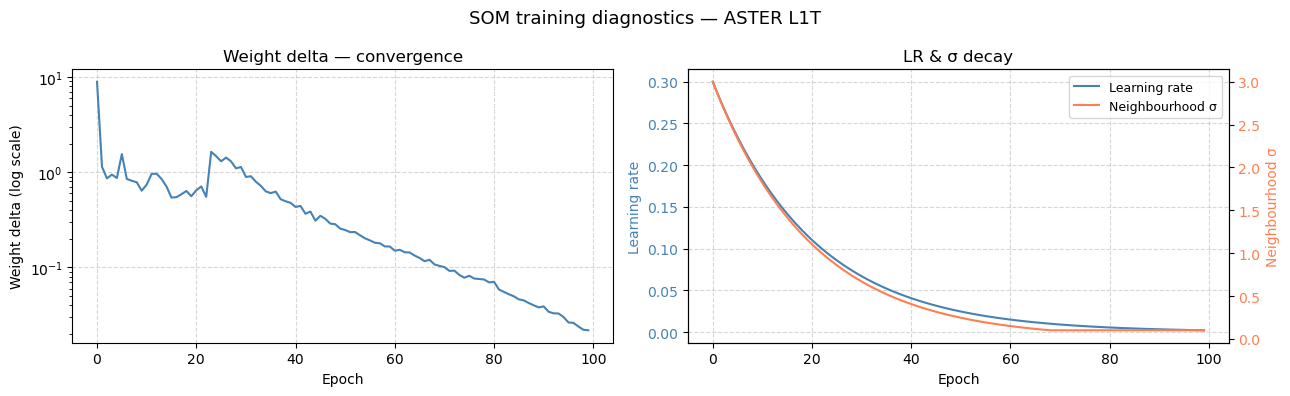

Saved → output/aster_som_training.png


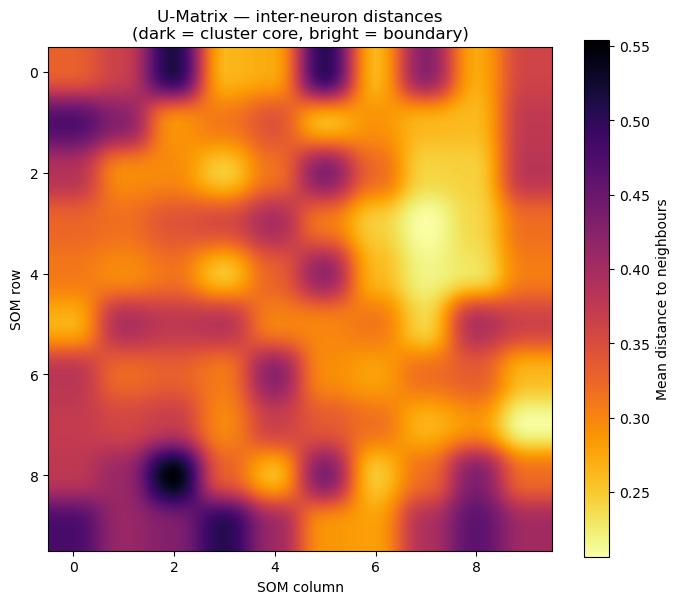

Saved → output/aster_som_umatrix.png


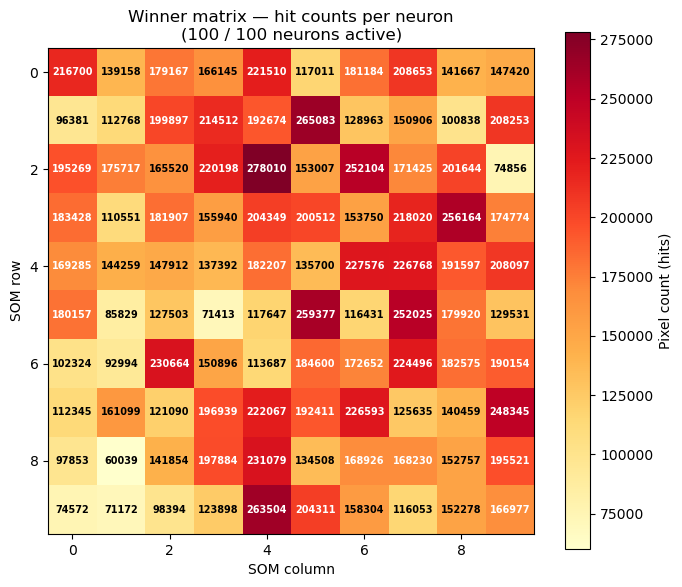

Saved → output/aster_som_winner.png


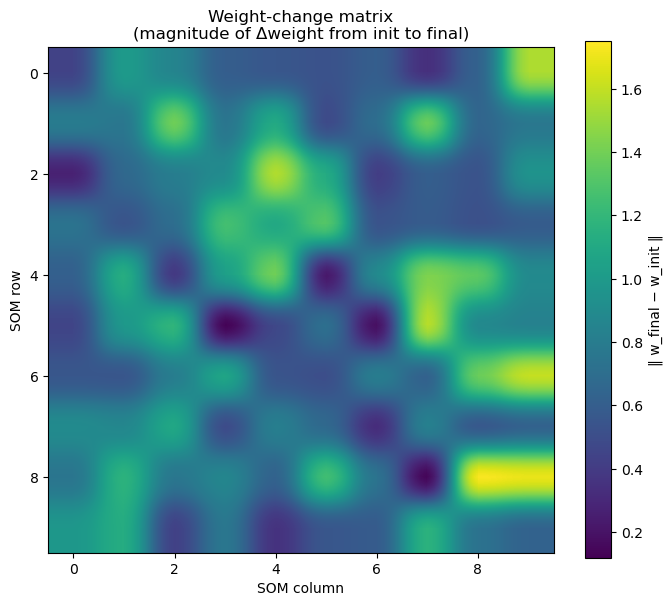

Saved → output/aster_som_weightchange.png


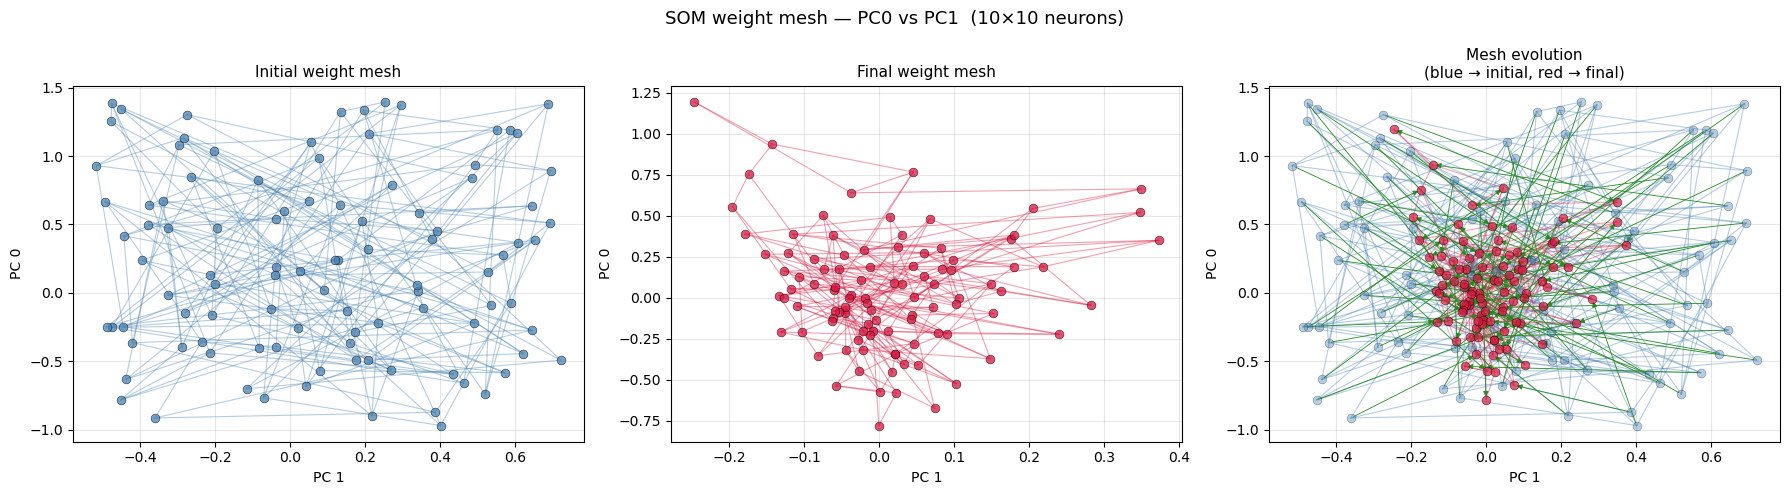

Saved → output/aster_som_mesh.png
Saved → output/aster_som_map_raw.png


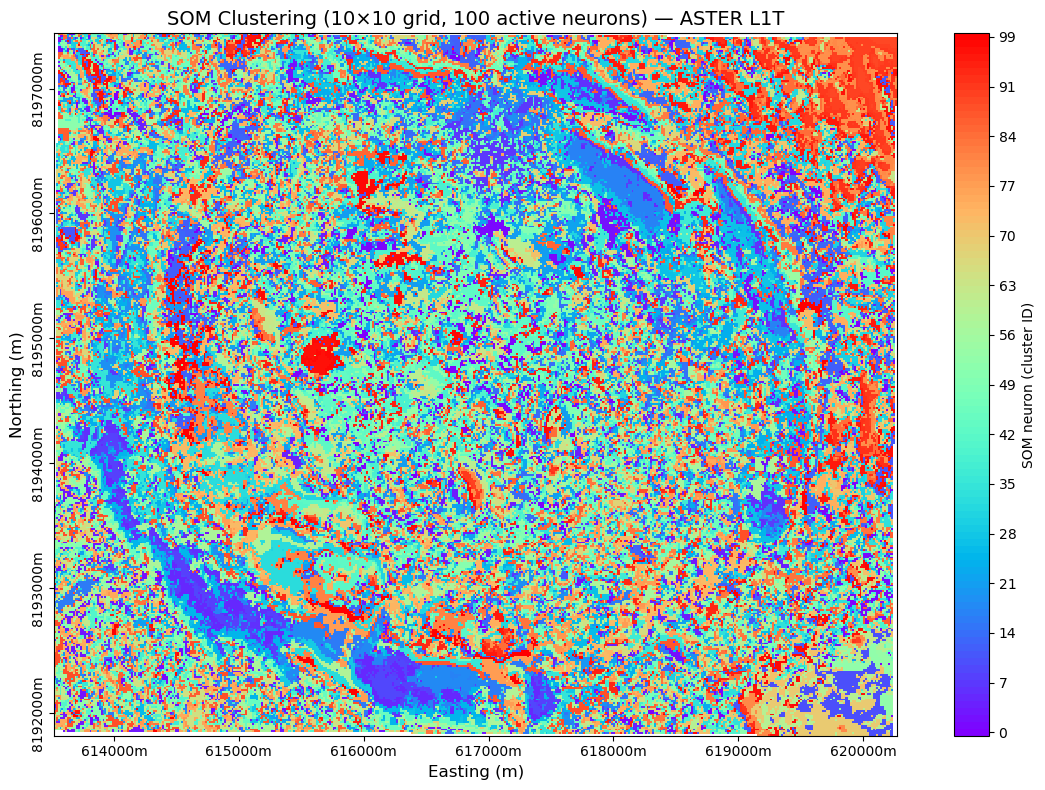

Saved → output/aster_som_map_filtered.png


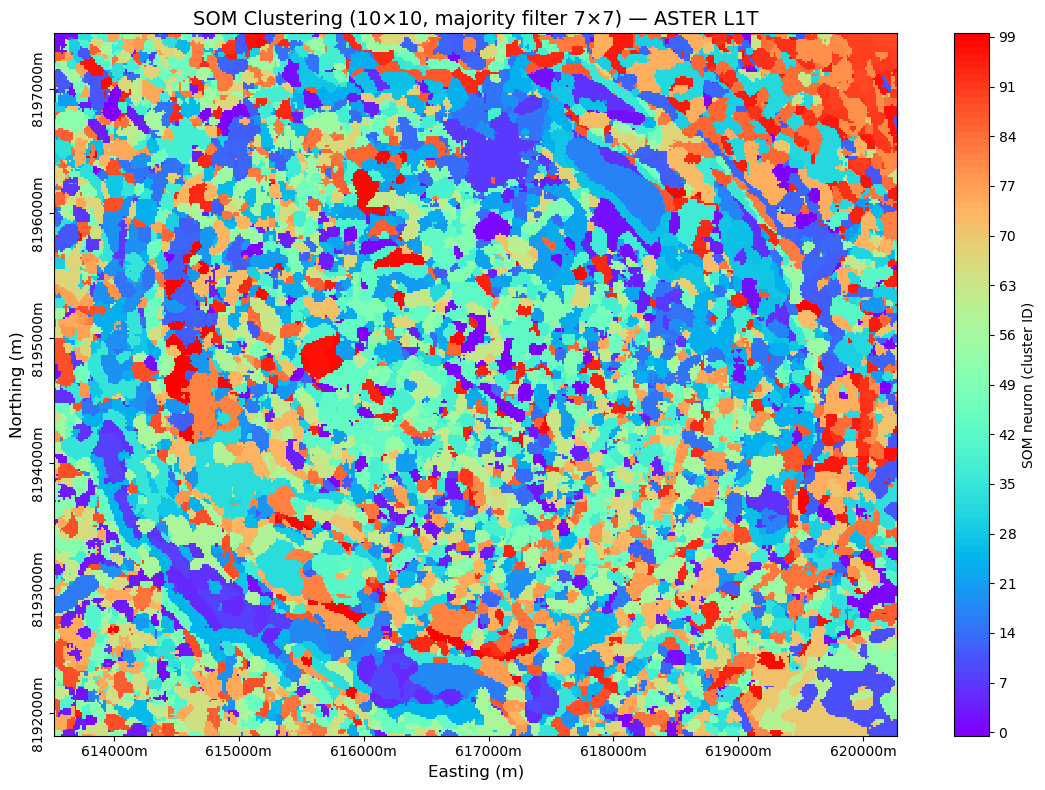


  Neuron        hits    % pixels
────────────────────────────────
       0     216,700     129.17%
       1     139,158      82.95%
       2     179,167     106.79%
       3     166,145      99.03%
       4     221,510     132.03%
       5     117,011      69.75%
       6     181,184     108.00%
       7     208,653     124.37%
       8     141,667      84.44%
       9     147,420      87.87%
      10      96,381      57.45%
      11     112,768      67.22%
      12     199,897     119.15%
      13     214,512     127.86%
      14     192,674     114.85%
      15     265,083     158.01%
      16     128,963      76.87%
      17     150,906      89.95%
      18     100,838      60.11%
      19     208,253     124.13%
      20     195,269     116.39%
      21     175,717     104.74%
      22     165,520      98.66%
      23     220,198     131.25%
      24     278,010     165.71%
      25     153,007      91.20%
      26     252,104     150.27%
      27     171,425     102.18%
      28 

In [3]:
"""
aster_som.py
============
SOM clustering on ASTER L1T data after PCA dimensionality reduction.
Uses the SOMTabular class (provided as a document) in place of MiniSom.

Pipeline mirror of aster_kmeans.py
-----------------------------------
Steps 0–3 (load → normalise → valid-pixel mask → PCA) are identical so
the two scripts can be run independently on the same datacube and their
results compared directly.

Outputs
-------
  output/aster_som_training.png       — delta / LR / sigma decay curves
  output/aster_som_umatrix.png        — U-matrix (cluster boundary map)
  output/aster_som_weightchange.png   — per-node weight-change magnitude
  output/aster_som_mesh.png           — weight mesh: initial vs final (2 PCs)
  output/aster_som_map_raw.png        — spatial cluster map (raw)
  output/aster_som_map_filtered.png   — spatial cluster map (majority filter)
"""

# ── paste or import the SOMTabular class here ────────────────────────────────
# If SOMTabular lives in a separate file (e.g. som_tabular.py), replace the
# block below with:  from som_tabular import SOMTabular
# ─────────────────────────────────────────────────────────────────────────────
# << INSERT SOMTabular CLASS DEFINITION HERE >>
# ─────────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.ndimage import generic_filter
from scipy.stats import mode
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
import rioxarray as rxr

# ---------------------------------------------------------------------------
# 0.  CONFIGURATION
# ---------------------------------------------------------------------------

DATACUBE_PATH  = "output/ASTER_datacube_reproj_clipped.tif"
OUTPUT_DIR     = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VAR_THRESHOLD  = 0.95     # keep enough PCs to explain this fraction of variance
RANDOM_STATE   = 42

# SOM grid — total neurons = SOM_ROWS × SOM_COLS → these become cluster IDs.
# Rule of thumb: 5×n_samples^0.5 neurons total, then choose a square root
# close to that.  For ASTER AOI (~50 k–200 k valid pixels) 10×10 is a good
# starting point.  Reduce to 7×7 or 5×5 for coarser lithological groupings.
SOM_ROWS       = 10
SOM_COLS       = 10

SOM_LR         = 0.3      # initial learning rate
SOM_SIGMA      = 3.0      # initial neighbourhood radius (grid units)
SOM_EPOCHS     = 100      # max training epochs
SOM_DECAY      = 0.05     # exponential decay rate per epoch
SOM_TOL        = 1e-10    # early-stopping tolerance on weight delta
SOM_PATIENCE   = 10       # consecutive stagnant epochs before early stop

FILTER_SIZE    = 7        # majority-filter kernel (odd number)

# Feature indices for the 2-D weight-mesh plots (which two PCs to display)
MESH_FEAT_X    = 1        # PC index for x-axis of mesh plot
MESH_FEAT_Y    = 0        # PC index for y-axis of mesh plot

# ---------------------------------------------------------------------------
# 1.  LOAD DATACUBE
# ---------------------------------------------------------------------------

datacube = rxr.open_rasterio(DATACUBE_PATH, masked=True)   # (Bands, Y, X)
print(f"Datacube shape : {datacube.shape}")
print(f"CRS            : {datacube.rio.crs}")

min_x = float(datacube.x.min())
max_x = float(datacube.x.max())
min_y = float(datacube.y.min())
max_y = float(datacube.y.max())
extent       = [min_x, max_x, min_y, max_y]
spatial_shape = (datacube.shape[1], datacube.shape[2])

# ---------------------------------------------------------------------------
# 2.  NORMALISE → FLATTEN → DROP NaN
# ---------------------------------------------------------------------------;4

data_yxb  = np.moveaxis(datacube.values, 0, -1)           # (Y, X, Bands)
min_vals  = np.nanmin(data_yxb, axis=(0, 1), keepdims=True)
max_vals  = np.nanmax(data_yxb, axis=(0, 1), keepdims=True)
data_norm = (data_yxb - min_vals) / (max_vals - min_vals + 1e-10)

n_px      = spatial_shape[0] * spatial_shape[1]
data_flat = data_norm.reshape(n_px, -1)

valid_mask = ~np.isnan(data_flat).any(axis=1)
data_valid = data_flat[valid_mask]
print(f"Valid pixels   : {data_valid.shape[0]:,} / {n_px:,} "
      f"({100 * data_valid.shape[0] / n_px:.1f} %)")

# ---------------------------------------------------------------------------
# 3.  PCA
# ---------------------------------------------------------------------------

pca            = PCA(random_state=RANDOM_STATE)
components_all = pca.fit_transform(data_valid)

var_ratio = pca.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)
n_keep    = int(np.searchsorted(cumvar, VAR_THRESHOLD)) + 1
X_pca     = components_all[:, :n_keep]

print(f"\nPCA — {n_keep} components kept "
      f"({100 * cumvar[n_keep - 1]:.1f} % variance explained)")
print(f"Per-component variance: {[round(v, 4) for v in var_ratio[:n_keep]]}")

# ---------------------------------------------------------------------------
# 4.  TRAIN SOM
# ---------------------------------------------------------------------------

n_neurons = SOM_ROWS * SOM_COLS
print(f"\nTraining SOM  {SOM_ROWS}×{SOM_COLS} = {n_neurons} neurons  "
      f"on {X_pca.shape[0]:,} samples × {X_pca.shape[1]} PCs …")

som = SOMTabular(
    n_features       = X_pca.shape[1],
    hiddenSize       = (SOM_ROWS, SOM_COLS),
    learningRate     = SOM_LR,
    neighborhoodSize = SOM_SIGMA,
    tol              = SOM_TOL,
    patience         = SOM_PATIENCE,
    track_per_node   = True,
    init             = "data",          # seed within PCA-space range
    feature_scaling  = None,            # PCA output is already normalised
    random_state     = RANDOM_STATE,
)

history = som.iterate(
    X_pca,
    epochs            = SOM_EPOCHS,
    randomInitialization = True,
    decay_rate        = SOM_DECAY,
    shuffle           = True,
    verbose           = True,
)

print(f"\nTraining finished — epochs run : {history['epochs_run']}, "
      f"converged : {history['converged']}, "
      f"final Δ : {history['final_delta']:.2e}")

# ---------------------------------------------------------------------------
# 5.  PREDICT  →  SPATIAL LABEL MAP
# ---------------------------------------------------------------------------

# predict() returns BMU indices in [0, n_neurons)
som_labels_valid = som.predict(X_pca)           # (n_valid_pixels,)

# Place labels back into the full spatial grid (NaN where data was masked)
labels_full = np.full(n_px, np.nan)
labels_full[valid_mask] = som_labels_valid.astype(float)
labels_2d   = labels_full.reshape(spatial_shape)

n_unique = len(np.unique(som_labels_valid))
print(f"\nActive SOM neurons : {n_unique} / {n_neurons}")

# ---------------------------------------------------------------------------
# 6.  MAJORITY FILTER
# ---------------------------------------------------------------------------

def filter_function(window_values):
    valid = window_values[~np.isnan(window_values)]
    if len(valid) == 0:
        return np.nan
    return float(mode(valid, keepdims=False).mode)

labels_major = generic_filter(labels_2d, function=filter_function, size=FILTER_SIZE)
print(f"Majority filter applied (kernel = {FILTER_SIZE}×{FILTER_SIZE})")

# ---------------------------------------------------------------------------
# 7.  TRAINING DIAGNOSTICS PLOT
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax_delta = axes[0]
ax_delta.semilogy(som.delta_history, linewidth=1.5, color='steelblue')
ax_delta.set_xlabel("Epoch")
ax_delta.set_ylabel("Weight delta (log scale)")
ax_delta.set_title("Weight delta — convergence")
ax_delta.grid(linestyle="--", alpha=0.5)

ax_lr = axes[1]
ax_lr2 = ax_lr.twinx()
l1, = ax_lr.plot(som.lr_history,    color="steelblue", linewidth=1.5, label="Learning rate")
l2, = ax_lr2.plot(som.sigma_history, color="coral",     linewidth=1.5, label="Neighbourhood σ")
ax_lr.set_xlabel("Epoch")
ax_lr.set_ylabel("Learning rate", color="steelblue")
ax_lr2.set_ylabel("Neighbourhood σ", color="coral")
ax_lr.tick_params(axis="y", labelcolor="steelblue")
ax_lr2.tick_params(axis="y", labelcolor="coral")
ax_lr.set_title("LR & σ decay")
ax_lr.legend(handles=[l1, l2], fontsize=9, loc="upper right")
ax_lr.grid(linestyle="--", alpha=0.5)

fig.suptitle("SOM training diagnostics — ASTER L1T", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_training.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_training.png")

# ---------------------------------------------------------------------------
# 8.  U-MATRIX  (cluster boundary detection)
# ---------------------------------------------------------------------------
#
# High U-matrix values = large distances between neighbouring neurons →
# likely cluster boundary.  Low values = smooth, dense region → cluster core.

umat = som.u_matrix()          # shape (SOM_ROWS, SOM_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(umat, cmap="inferno_r", interpolation="kaiser", origin="upper")
ax.set_title("U-Matrix — inter-neuron distances\n"
             "(dark = cluster core, bright = boundary)",
             fontsize=12)
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")
plt.colorbar(im, ax=ax, label="Mean distance to neighbours")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_umatrix.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_umatrix.png")

# ---------------------------------------------------------------------------
# 9.  WINNER (HIT-COUNT) MATRIX
# ---------------------------------------------------------------------------
#
# Shows how many pixels each neuron was the BMU for.
# Dead neurons (0 hits) are over-parameterisation — reduce the grid.
# Highly dominant neurons suggest a very dense cluster.

winner_mat = som.get_winner_matrix()   # shape (SOM_ROWS, SOM_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(winner_mat, cmap="YlOrRd", interpolation="none", origin="upper")
ax.set_title(f"Winner matrix — hit counts per neuron\n"
             f"({int(np.sum(winner_mat > 0))} / {n_neurons} neurons active)",
             fontsize=12)
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")

# Annotate each cell with its count
for r in range(SOM_ROWS):
    for c in range(SOM_COLS):
        count = int(winner_mat[r, c])
        color = "white" if count > winner_mat.max() * 0.6 else "black"
        ax.text(c, r, str(count), ha="center", va="center",
                fontsize=7, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, label="Pixel count (hits)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_winner.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_winner.png")

# ---------------------------------------------------------------------------
# 10.  WEIGHT-CHANGE MATRIX
# ---------------------------------------------------------------------------
#
# How much each neuron moved during training.
# Neurons with near-zero change never adapted — they may be dead or
# trapped in a low-density region of the PC space.

wchange = som.get_weight_change_matrix()   # shape (SOM_ROWS, SOM_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(wchange, cmap="viridis", interpolation="kaiser", origin="upper")
ax.set_title("Weight-change matrix\n"
             "(magnitude of Δweight from init to final)",
             fontsize=12)
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")
plt.colorbar(im, ax=ax, label="‖ w_final − w_init ‖")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_weightchange.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_weightchange.png")

# ---------------------------------------------------------------------------
# 11.  WEIGHT MESH EVOLUTION  (PC₀ vs PC₁)
# ---------------------------------------------------------------------------
#
# Each dot = one SOM neuron in PCA feature space.
# Connections follow the grid topology.
# The mesh should "unfold" from a random tangle (blue) into a smooth
# surface (red) that covers the data manifold.  A tangled final mesh
# means insufficient training epochs or learning rate too low.

def _draw_mesh(ax, weights_np, rows, cols, feat_x, feat_y,
               color, title, alpha_nodes=0.75):
    """Draw neuron grid in 2-D PC space."""
    wg = weights_np.reshape(rows, cols, -1)

    # Horizontal edges
    for r in range(rows):
        for c in range(cols - 1):
            ax.plot([wg[r, c, feat_x], wg[r, c + 1, feat_x]],
                    [wg[r, c, feat_y], wg[r, c + 1, feat_y]],
                    color=color, alpha=0.4, linewidth=0.8)
    # Vertical edges
    for r in range(rows - 1):
        for c in range(cols):
            ax.plot([wg[r, c, feat_x], wg[r + 1, c, feat_x]],
                    [wg[r, c, feat_y], wg[r + 1, c, feat_y]],
                    color=color, alpha=0.4, linewidth=0.8)
    # Nodes
    ax.scatter(wg[:, :, feat_x].flatten(),
               wg[:, :, feat_y].flatten(),
               c=color, s=40, alpha=alpha_nodes,
               edgecolors="black", linewidth=0.4, zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"PC {feat_x}")
    ax.set_ylabel(f"PC {feat_y}")
    ax.grid(True, alpha=0.3)


# Initial weights are stored in original (unscaled) internal units —
# same space as X_pca because we set feature_scaling=None.
w_init  = som.initial_weights.detach().cpu().numpy()
w_final = som.weights_Kohonen.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_draw_mesh(axes[0], w_init,  SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="steelblue", title="Initial weight mesh")

_draw_mesh(axes[1], w_final, SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="crimson", title="Final weight mesh")

# Overlay panel — both meshes + movement arrows
_draw_mesh(axes[2], w_init,  SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="steelblue", title="Mesh evolution\n(blue → initial, red → final)",
           alpha_nodes=0.4)
_draw_mesh(axes[2], w_final, SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="crimson", title="Mesh evolution\n(blue → initial, red → final)",
           alpha_nodes=0.7)
# Movement arrows (draw only where shift is meaningful)
for i in range(n_neurons):
    dx = float(w_final[i, MESH_FEAT_X] - w_init[i, MESH_FEAT_X])
    dy = float(w_final[i, MESH_FEAT_Y] - w_init[i, MESH_FEAT_Y])
    if np.hypot(dx, dy) > 0.01:
        axes[2].annotate(
            "", xy=(w_final[i, MESH_FEAT_X], w_final[i, MESH_FEAT_Y]),
            xytext=(w_init[i, MESH_FEAT_X], w_init[i, MESH_FEAT_Y]),
            arrowprops=dict(arrowstyle="-|>", color="forestgreen",
                            lw=0.6, mutation_scale=8),
            zorder=4,
        )

fig.suptitle(f"SOM weight mesh — PC{MESH_FEAT_Y} vs PC{MESH_FEAT_X}  "
             f"({SOM_ROWS}×{SOM_COLS} neurons)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_mesh.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_mesh.png")

# ---------------------------------------------------------------------------
# 12.  SPATIAL CLUSTER MAPS
# ---------------------------------------------------------------------------

def plot_map(array, extent, n_clusters, title="SOM Clustering", save_path=None):
    """
    Render a discrete cluster-label raster as a colour image.

    Parameters
    ----------
    array      : 2-D numpy array  (NaN = masked / no-data)
    extent     : [left, right, bottom, top] in the datacube CRS
    n_clusters : number of unique clusters (sets discrete colourmap)
    title      : figure title string
    save_path  : if given, saves at 300 dpi
    """
    try:
        cmap = mpl.colormaps["rainbow"].resampled(n_clusters)
    except AttributeError:
        cmap = cm.get_cmap("rainbow", n_clusters)

    array_masked = np.ma.masked_invalid(array)

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(
        array_masked,
        cmap=cmap,
        vmin=-0.5, vmax=n_clusters - 0.5,
        extent=extent,
        origin="upper",
        interpolation="nearest",
    )

    # Axis formatting: degrees vs UTM metres
    if abs(extent[0]) < 360:
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f°"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f°"))
        ax.set_xlabel("Longitude", fontsize=12)
        ax.set_ylabel("Latitude", fontsize=12)
    else:
        ax.xaxis.set_major_formatter(FormatStrFormatter("%dm"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%dm"))
        ax.set_xlabel("Easting (m)", fontsize=12)
        ax.set_ylabel("Northing (m)", fontsize=12)

    plt.yticks(rotation=90, va="center")

    cbar = plt.colorbar(im, ax=ax, label="SOM neuron (cluster ID)")
    tick_locs = np.linspace(0, n_clusters - 1, min(n_clusters, 15))
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels([str(int(t)) for t in tick_locs])

    ax.set_title(title, fontsize=14)
    ax.grid(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


plot_map(
    labels_2d, extent, n_unique,
    title=f"SOM Clustering ({SOM_ROWS}×{SOM_COLS} grid, {n_unique} active neurons) — ASTER L1T",
    save_path=f"{OUTPUT_DIR}/aster_som_map_raw.png",
)

plot_map(
    labels_major, extent, n_unique,
    title=(f"SOM Clustering ({SOM_ROWS}×{SOM_COLS}, majority filter {FILTER_SIZE}×{FILTER_SIZE})"
           f" — ASTER L1T"),
    save_path=f"{OUTPUT_DIR}/aster_som_map_filtered.png",
)

# ---------------------------------------------------------------------------
# 13.  SUMMARY TABLE
# ---------------------------------------------------------------------------

winner_flat = som.winner_counts
print(f"\n{'Neuron':>8}  {'hits':>10}  {'% pixels':>10}")
print("─" * 32)
for nid in range(n_neurons):
    hits = int(winner_flat[nid])
    if hits > 0:
        pct = 100.0 * hits / data_valid.shape[0]
        print(f"{nid:>8}  {hits:>10,}  {pct:>9.2f}%")

dead = int(np.sum(winner_flat == 0))
print(f"\nDead neurons : {dead} / {n_neurons}  "
      f"({'reduce grid' if dead > n_neurons * 0.2 else 'acceptable'})")

Datacube shape : (9, 376, 451)
CRS            : EPSG:32736
Valid pixels   : 167,768 / 169,576 (98.9 %)

Training SOM  3×3 = 9 neurons  on 167,768 samples × 4 PCs …
Epoch 10/100: Δ=6.10e-01, LR=0.1913, σ=1.91
Epoch 20/100: Δ=3.29e-01, LR=0.1160, σ=1.16
Epoch 30/100: Δ=5.96e-01, LR=0.0704, σ=0.70
Epoch 40/100: Δ=1.27e-01, LR=0.0427, σ=0.43
Epoch 50/100: Δ=1.14e-01, LR=0.0259, σ=0.26
Epoch 60/100: Δ=1.12e-01, LR=0.0157, σ=0.16
Epoch 70/100: Δ=8.68e-02, LR=0.0095, σ=0.10
Epoch 80/100: Δ=5.35e-02, LR=0.0058, σ=0.10
Epoch 90/100: Δ=3.42e-02, LR=0.0035, σ=0.10
Epoch 100/100: Δ=3.17e-02, LR=0.0021, σ=0.10

Training finished — epochs run : 100, converged : False, final Δ : 3.17e-02

Active SOM neurons : 9 / 9
Majority filter applied (kernel = 7×7)


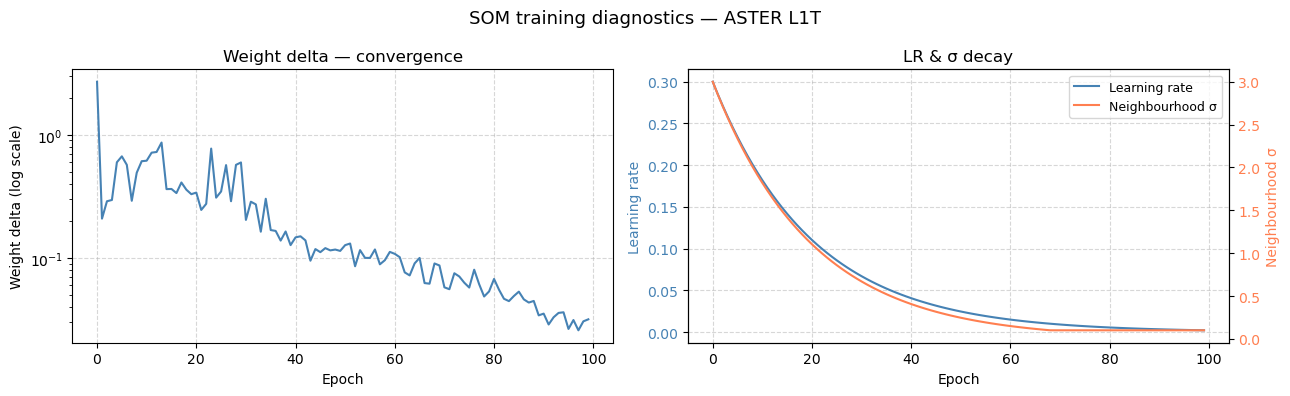

Saved → output/aster_som_training.png


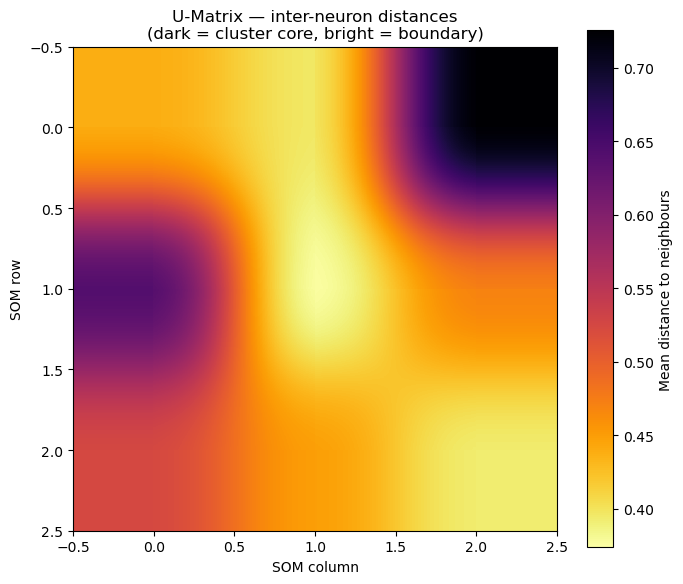

Saved → output/aster_som_umatrix.png


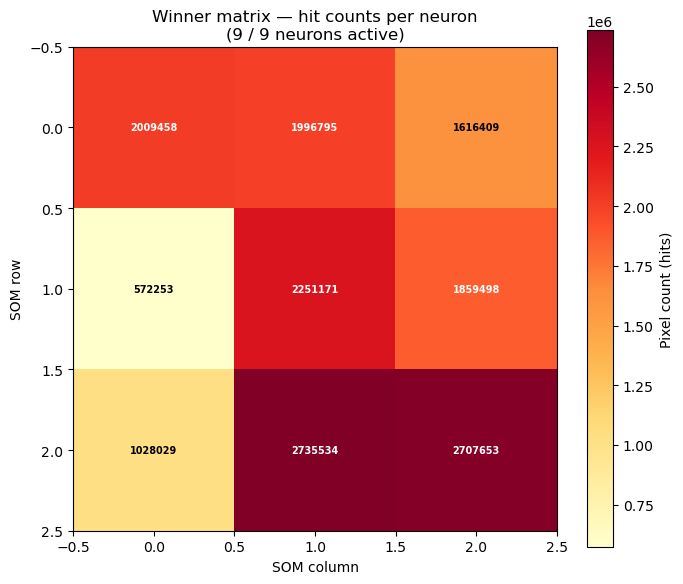

Saved → output/aster_som_winner.png


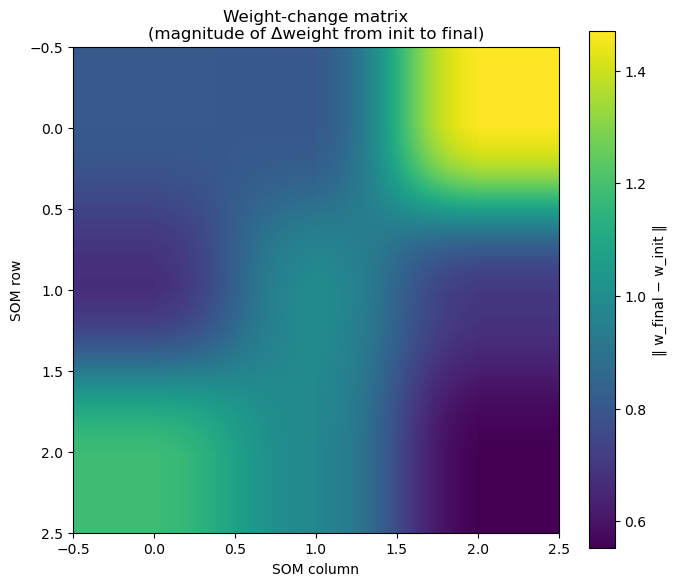

Saved → output/aster_som_weightchange.png


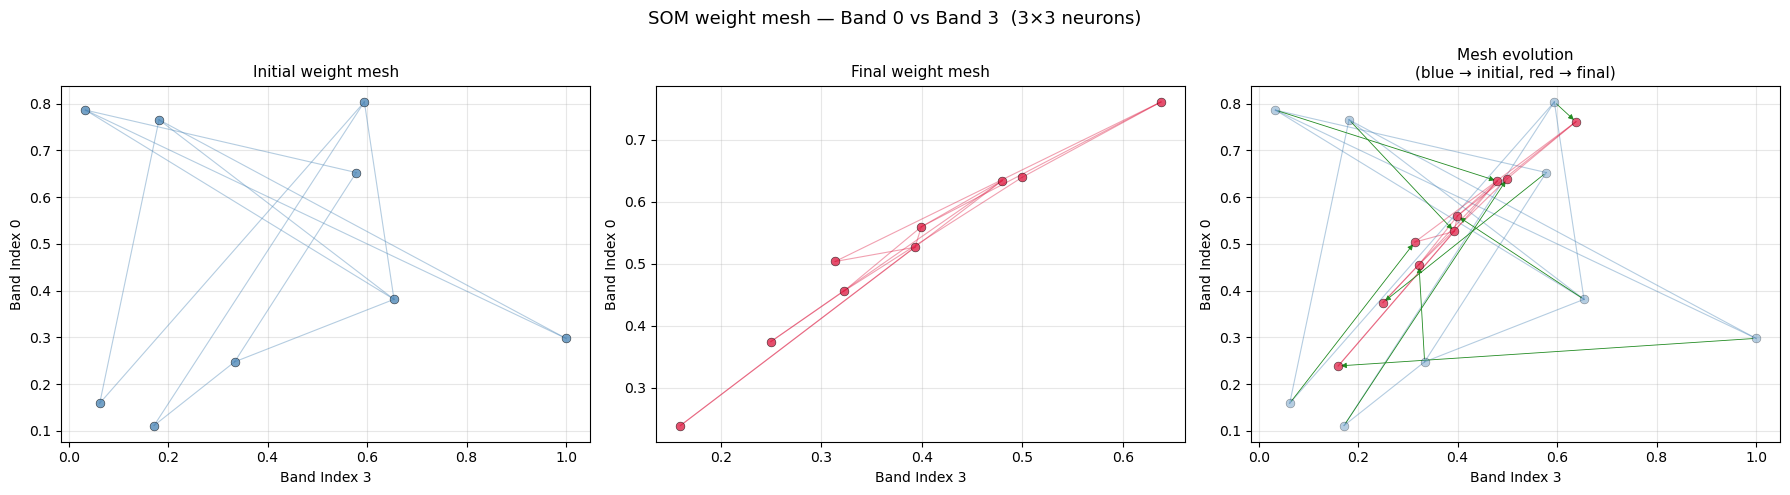

Saved → output/aster_som_mesh.png
Saved → output/aster_som_map_raw.png


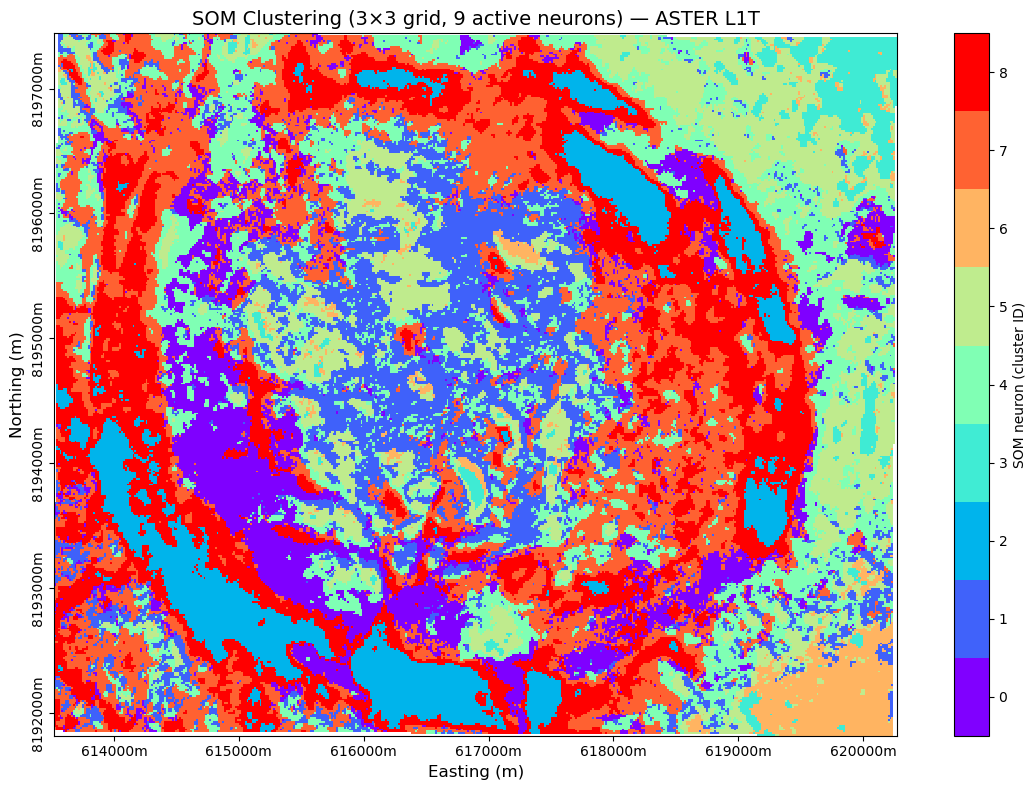

Saved → output/aster_som_map_filtered.png


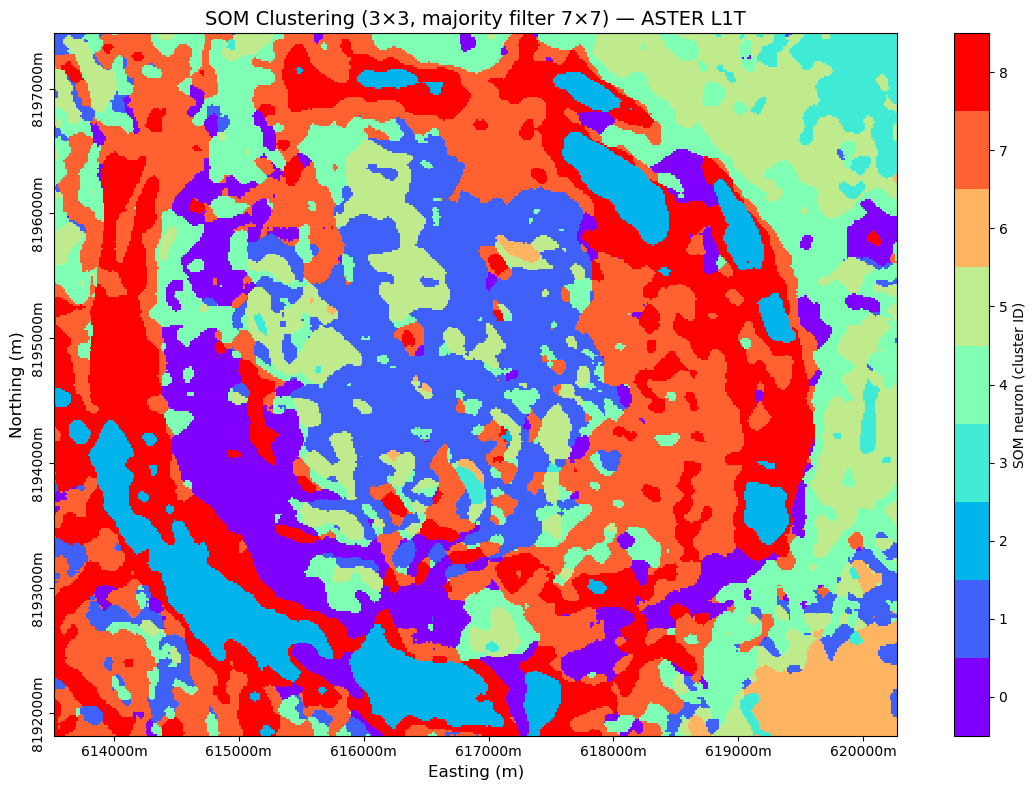


  Neuron        hits    % pixels
────────────────────────────────
       0   2,009,458    1197.76%
       1   1,996,795    1190.21%
       2   1,616,409     963.48%
       3     572,253     341.10%
       4   2,251,171    1341.84%
       5   1,859,498    1108.37%
       6   1,028,029     612.77%
       7   2,735,534    1630.55%
       8   2,707,653    1613.93%

Dead neurons : 0 / 9  (acceptable)


In [7]:
# ── paste or import the SOMTabular class here ────────────────────────────────
# If SOMTabular lives in a separate file (e.g. som_tabular.py), replace the
# block below with:  from som_tabular import SOMTabular
# ─────────────────────────────────────────────────────────────────────────────
# << INSERT SOMTabular CLASS DEFINITION HERE >>
# ─────────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.ndimage import generic_filter
from scipy.stats import mode
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
import rioxarray as rxr

# ---------------------------------------------------------------------------
# 0.  CONFIGURATION
# ---------------------------------------------------------------------------

DATACUBE_PATH  = "output/ASTER_datacube_reproj_clipped.tif"
OUTPUT_DIR     = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VAR_THRESHOLD  = 0.95     # keep enough PCs to explain this fraction of variance
RANDOM_STATE   = 42

# SOM grid — total neurons = SOM_ROWS × SOM_COLS → these become cluster IDs.
# Rule of thumb: 5×n_samples^0.5 neurons total, then choose a square root
# close to that.  For ASTER AOI (~50 k–200 k valid pixels) 10×10 is a good
# starting point.  Reduce to 7×7 or 5×5 for coarser lithological groupings.
SOM_ROWS       = 3
SOM_COLS       = 3

SOM_LR         = 0.3      # initial learning rate
SOM_SIGMA      = 3.0      # initial neighbourhood radius (grid units)
SOM_EPOCHS     = 100      # max training epochs
SOM_DECAY      = 0.05     # exponential decay rate per epoch
SOM_TOL        = 1e-10    # early-stopping tolerance on weight delta
SOM_PATIENCE   = 10       # consecutive stagnant epochs before early stop

FILTER_SIZE    = 7        # majority-filter kernel (odd number)

# Feature indices for the 2-D weight-mesh plots (which two PCs to display)
MESH_FEAT_X    = 3       # PC index for x-axis of mesh plot
MESH_FEAT_Y    = 0        # PC index for y-axis of mesh plot

# ---------------------------------------------------------------------------
# 1.  LOAD DATACUBE
# ---------------------------------------------------------------------------

datacube = rxr.open_rasterio(DATACUBE_PATH, masked=True)   # (Bands, Y, X)
print(f"Datacube shape : {datacube.shape}")
print(f"CRS            : {datacube.rio.crs}")

min_x = float(datacube.x.min())
max_x = float(datacube.x.max())
min_y = float(datacube.y.min())
max_y = float(datacube.y.max())
extent       = [min_x, max_x, min_y, max_y]
spatial_shape = (datacube.shape[1], datacube.shape[2])

# ---------------------------------------------------------------------------
# 2.  NORMALISE → FLATTEN → DROP NaN
# ---------------------------------------------------------------------------

data_yxb  = np.moveaxis(datacube.values, 0, -1)           # (Y, X, Bands)
min_vals  = np.nanmin(data_yxb, axis=(0, 1), keepdims=True)
max_vals  = np.nanmax(data_yxb, axis=(0, 1), keepdims=True)
data_norm = (data_yxb - min_vals) / (max_vals - min_vals + 1e-10)

n_px      = spatial_shape[0] * spatial_shape[1]
data_flat = data_norm.reshape(n_px, -1)

valid_mask = ~np.isnan(data_flat).any(axis=1)
data_valid = data_flat[valid_mask]
print(f"Valid pixels   : {data_valid.shape[0]:,} / {n_px:,} "
      f"({100 * data_valid.shape[0] / n_px:.1f} %)")

# ---------------------------------------------------------------------------
# 3.  PCA
# ---------------------------------------------------------------------------

#pca            = PCA(random_state=RANDOM_STATE)
#components_all = pca.fit_transform(data_valid)

#var_ratio = pca.explained_variance_ratio_
#cumvar    = np.cumsum(var_ratio)
#n_keep    = int(np.searchsorted(cumvar, VAR_THRESHOLD)) + 1
#X_pca     = components_all[:, :n_keep]

#print(f"\nPCA — {n_keep} components kept "
#      f"({100 * cumvar[n_keep - 1]:.1f} % variance explained)")
#print(f"Per-component variance: {[round(v, 4) for v in var_ratio[:n_keep]]}")

# ---------------------------------------------------------------------------
# 4.  TRAIN SOM
# ---------------------------------------------------------------------------

n_neurons = SOM_ROWS * SOM_COLS
print(f"\nTraining SOM  {SOM_ROWS}×{SOM_COLS} = {n_neurons} neurons  "
      f"on {X_pca.shape[0]:,} samples × {X_pca.shape[1]} PCs …")

som = SOMTabular(
    n_features       = data_valid.shape[1],
    hiddenSize       = (SOM_ROWS, SOM_COLS),
    learningRate     = SOM_LR,
    neighborhoodSize = SOM_SIGMA,
    tol              = SOM_TOL,
    patience         = SOM_PATIENCE,
    track_per_node   = True,
    init             = "data",          # seed within PCA-space range
    feature_scaling  = None,            # data_valid is already min-max scaled
    random_state     = RANDOM_STATE,
)

history = som.iterate(
    data_valid,
    epochs            = SOM_EPOCHS,
    randomInitialization = True,
    decay_rate        = SOM_DECAY,
    shuffle           = True,
    verbose           = True,
)

print(f"\nTraining finished — epochs run : {history['epochs_run']}, "
      f"converged : {history['converged']}, "
      f"final Δ : {history['final_delta']:.2e}")

# ---------------------------------------------------------------------------
# 5.  PREDICT  →  SPATIAL LABEL MAP
# ---------------------------------------------------------------------------

# predict() returns BMU indices in [0, n_neurons)
som_labels_valid = som.predict(data_valid)           # (n_valid_pixels,)

# Place labels back into the full spatial grid (NaN where data was masked)
labels_full = np.full(n_px, np.nan)
labels_full[valid_mask] = som_labels_valid.astype(float)
labels_2d   = labels_full.reshape(spatial_shape)

n_unique = len(np.unique(som_labels_valid))
print(f"\nActive SOM neurons : {n_unique} / {n_neurons}")

# ---------------------------------------------------------------------------
# 6.  MAJORITY FILTER
# ---------------------------------------------------------------------------

def filter_function(window_values):
    valid = window_values[~np.isnan(window_values)]
    if len(valid) == 0:
        return np.nan
    return float(mode(valid, keepdims=False).mode)

labels_major = generic_filter(labels_2d, function=filter_function, size=FILTER_SIZE)
print(f"Majority filter applied (kernel = {FILTER_SIZE}×{FILTER_SIZE})")

# ---------------------------------------------------------------------------
# 7.  TRAINING DIAGNOSTICS PLOT
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax_delta = axes[0]
ax_delta.semilogy(som.delta_history, linewidth=1.5, color='steelblue')
ax_delta.set_xlabel("Epoch")
ax_delta.set_ylabel("Weight delta (log scale)")
ax_delta.set_title("Weight delta — convergence")
ax_delta.grid(linestyle="--", alpha=0.5)

ax_lr = axes[1]
ax_lr2 = ax_lr.twinx()
l1, = ax_lr.plot(som.lr_history,    color="steelblue", linewidth=1.5, label="Learning rate")
l2, = ax_lr2.plot(som.sigma_history, color="coral",     linewidth=1.5, label="Neighbourhood σ")
ax_lr.set_xlabel("Epoch")
ax_lr.set_ylabel("Learning rate", color="steelblue")
ax_lr2.set_ylabel("Neighbourhood σ", color="coral")
ax_lr.tick_params(axis="y", labelcolor="steelblue")
ax_lr2.tick_params(axis="y", labelcolor="coral")
ax_lr.set_title("LR & σ decay")
ax_lr.legend(handles=[l1, l2], fontsize=9, loc="upper right")
ax_lr.grid(linestyle="--", alpha=0.5)

fig.suptitle("SOM training diagnostics — ASTER L1T", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_training.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_training.png")

# ---------------------------------------------------------------------------
# 8.  U-MATRIX  (cluster boundary detection)
# ---------------------------------------------------------------------------
#
# High U-matrix values = large distances between neighbouring neurons →
# likely cluster boundary.  Low values = smooth, dense region → cluster core.

umat = som.u_matrix()          # shape (SOM_ROWS, SOM_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(umat, cmap="inferno_r", interpolation="kaiser", origin="upper")
ax.set_title("U-Matrix — inter-neuron distances\n"
             "(dark = cluster core, bright = boundary)",
             fontsize=12)
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")
plt.colorbar(im, ax=ax, label="Mean distance to neighbours")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_umatrix.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_umatrix.png")

# ---------------------------------------------------------------------------
# 9.  WINNER (HIT-COUNT) MATRIX
# ---------------------------------------------------------------------------
#
# Shows how many pixels each neuron was the BMU for.
# Dead neurons (0 hits) are over-parameterisation — reduce the grid.
# Highly dominant neurons suggest a very dense cluster.

winner_mat = som.get_winner_matrix()   # shape (SOM_ROWS, SOM_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(winner_mat, cmap="YlOrRd", interpolation="none", origin="upper")
ax.set_title(f"Winner matrix — hit counts per neuron\n"
             f"({int(np.sum(winner_mat > 0))} / {n_neurons} neurons active)",
             fontsize=12)
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")

# Annotate each cell with its count
for r in range(SOM_ROWS):
    for c in range(SOM_COLS):
        count = int(winner_mat[r, c])
        color = "white" if count > winner_mat.max() * 0.6 else "black"
        ax.text(c, r, str(count), ha="center", va="center",
                fontsize=7, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, label="Pixel count (hits)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_winner.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_winner.png")

# ---------------------------------------------------------------------------
# 10.  WEIGHT-CHANGE MATRIX
# ---------------------------------------------------------------------------
#
# How much each neuron moved during training.
# Neurons with near-zero change never adapted — they may be dead or
# trapped in a low-density region of the PC space.

wchange = som.get_weight_change_matrix()   # shape (SOM_ROWS, SOM_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(wchange, cmap="viridis", interpolation="kaiser", origin="upper")
ax.set_title("Weight-change matrix\n"
             "(magnitude of Δweight from init to final)",
             fontsize=12)
ax.set_xlabel("SOM column")
ax.set_ylabel("SOM row")
plt.colorbar(im, ax=ax, label="‖ w_final − w_init ‖")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_weightchange.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_weightchange.png")

# ---------------------------------------------------------------------------
# 11.  WEIGHT MESH EVOLUTION  (PC₀ vs PC₁)
# ---------------------------------------------------------------------------
#
# Each dot = one SOM neuron in PCA feature space.
# Connections follow the grid topology.
# The mesh should "unfold" from a random tangle (blue) into a smooth
# surface (red) that covers the data manifold.  A tangled final mesh
# means insufficient training epochs or learning rate too low.

def _draw_mesh(ax, weights_np, rows, cols, feat_x, feat_y,
               color, title, alpha_nodes=0.75):
    """Draw neuron grid in 2-D PC space."""
    wg = weights_np.reshape(rows, cols, -1)

    # Horizontal edges
    for r in range(rows):
        for c in range(cols - 1):
            ax.plot([wg[r, c, feat_x], wg[r, c + 1, feat_x]],
                    [wg[r, c, feat_y], wg[r, c + 1, feat_y]],
                    color=color, alpha=0.4, linewidth=0.8)
    # Vertical edges
    for r in range(rows - 1):
        for c in range(cols):
            ax.plot([wg[r, c, feat_x], wg[r + 1, c, feat_x]],
                    [wg[r, c, feat_y], wg[r + 1, c, feat_y]],
                    color=color, alpha=0.4, linewidth=0.8)
    # Nodes
    ax.scatter(wg[:, :, feat_x].flatten(),
               wg[:, :, feat_y].flatten(),
               c=color, s=40, alpha=alpha_nodes,
               edgecolors="black", linewidth=0.4, zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"Band Index {feat_x}")
    ax.set_ylabel(f"Band Index {feat_y}")
    ax.grid(True, alpha=0.3)


# Initial weights are stored in original (unscaled) internal units —
# same space as X_pca because we set feature_scaling=None.
w_init  = som.initial_weights.detach().cpu().numpy()
w_final = som.weights_Kohonen.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_draw_mesh(axes[0], w_init,  SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="steelblue", title="Initial weight mesh")

_draw_mesh(axes[1], w_final, SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="crimson", title="Final weight mesh")

# Overlay panel — both meshes + movement arrows
_draw_mesh(axes[2], w_init,  SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="steelblue", title="Mesh evolution\n(blue → initial, red → final)",
           alpha_nodes=0.4)
_draw_mesh(axes[2], w_final, SOM_ROWS, SOM_COLS,
           MESH_FEAT_X, MESH_FEAT_Y,
           color="crimson", title="Mesh evolution\n(blue → initial, red → final)",
           alpha_nodes=0.7)
# Movement arrows (draw only where shift is meaningful)
for i in range(n_neurons):
    dx = float(w_final[i, MESH_FEAT_X] - w_init[i, MESH_FEAT_X])
    dy = float(w_final[i, MESH_FEAT_Y] - w_init[i, MESH_FEAT_Y])
    if np.hypot(dx, dy) > 0.01:
        axes[2].annotate(
            "", xy=(w_final[i, MESH_FEAT_X], w_final[i, MESH_FEAT_Y]),
            xytext=(w_init[i, MESH_FEAT_X], w_init[i, MESH_FEAT_Y]),
            arrowprops=dict(arrowstyle="-|>", color="forestgreen",
                            lw=0.6, mutation_scale=8),
            zorder=4,
        )

fig.suptitle(f"SOM weight mesh — Band {MESH_FEAT_Y} vs Band {MESH_FEAT_X}  "
             f"({SOM_ROWS}×{SOM_COLS} neurons)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_mesh.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/aster_som_mesh.png")

# ---------------------------------------------------------------------------
# 12.  SPATIAL CLUSTER MAPS
# ---------------------------------------------------------------------------

def plot_map(array, extent, n_clusters, title="SOM Clustering", save_path=None):
    """
    Render a discrete cluster-label raster as a colour image.

    Parameters
    ----------
    array      : 2-D numpy array  (NaN = masked / no-data)
    extent     : [left, right, bottom, top] in the datacube CRS
    n_clusters : number of unique clusters (sets discrete colourmap)
    title      : figure title string
    save_path  : if given, saves at 300 dpi
    """
    try:
        cmap = mpl.colormaps["rainbow"].resampled(n_clusters)
    except AttributeError:
        cmap = cm.get_cmap("rainbow", n_clusters)

    array_masked = np.ma.masked_invalid(array)

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(
        array_masked,
        cmap=cmap,
        vmin=-0.5, vmax=n_clusters - 0.5,
        extent=extent,
        origin="upper",
        interpolation="nearest",
    )

    # Axis formatting: degrees vs UTM metres
    if abs(extent[0]) < 360:
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f°"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f°"))
        ax.set_xlabel("Longitude", fontsize=12)
        ax.set_ylabel("Latitude", fontsize=12)
    else:
        ax.xaxis.set_major_formatter(FormatStrFormatter("%dm"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%dm"))
        ax.set_xlabel("Easting (m)", fontsize=12)
        ax.set_ylabel("Northing (m)", fontsize=12)

    plt.yticks(rotation=90, va="center")

    cbar = plt.colorbar(im, ax=ax, label="SOM neuron (cluster ID)")
    tick_locs = np.linspace(0, n_clusters - 1, min(n_clusters, 15))
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels([str(int(t)) for t in tick_locs])

    ax.set_title(title, fontsize=14)
    ax.grid(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


plot_map(
    labels_2d, extent, n_unique,
    title=f"SOM Clustering ({SOM_ROWS}×{SOM_COLS} grid, {n_unique} active neurons) — ASTER L1T",
    save_path=f"{OUTPUT_DIR}/aster_som_map_raw.png",
)

plot_map(
    labels_major, extent, n_unique,
    title=(f"SOM Clustering ({SOM_ROWS}×{SOM_COLS}, majority filter {FILTER_SIZE}×{FILTER_SIZE})"
           f" — ASTER L1T"),
    save_path=f"{OUTPUT_DIR}/aster_som_map_filtered.png",
)

# ---------------------------------------------------------------------------
# 13.  SUMMARY TABLE
# ---------------------------------------------------------------------------

winner_flat = som.winner_counts
print(f"\n{'Neuron':>8}  {'hits':>10}  {'% pixels':>10}")
print("─" * 32)
for nid in range(n_neurons):
    hits = int(winner_flat[nid])
    if hits > 0:
        pct = 100.0 * hits / data_valid.shape[0]
        print(f"{nid:>8}  {hits:>10,}  {pct:>9.2f}%")

dead = int(np.sum(winner_flat == 0))
print(f"\nDead neurons : {dead} / {n_neurons}  "
      f"({'reduce grid' if dead > n_neurons * 0.2 else 'acceptable'})")


[Warning] Wavelength list length (6) does not match data bands (9). Using band indices instead.


C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_21416\2745519559.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", n_top_dominant)


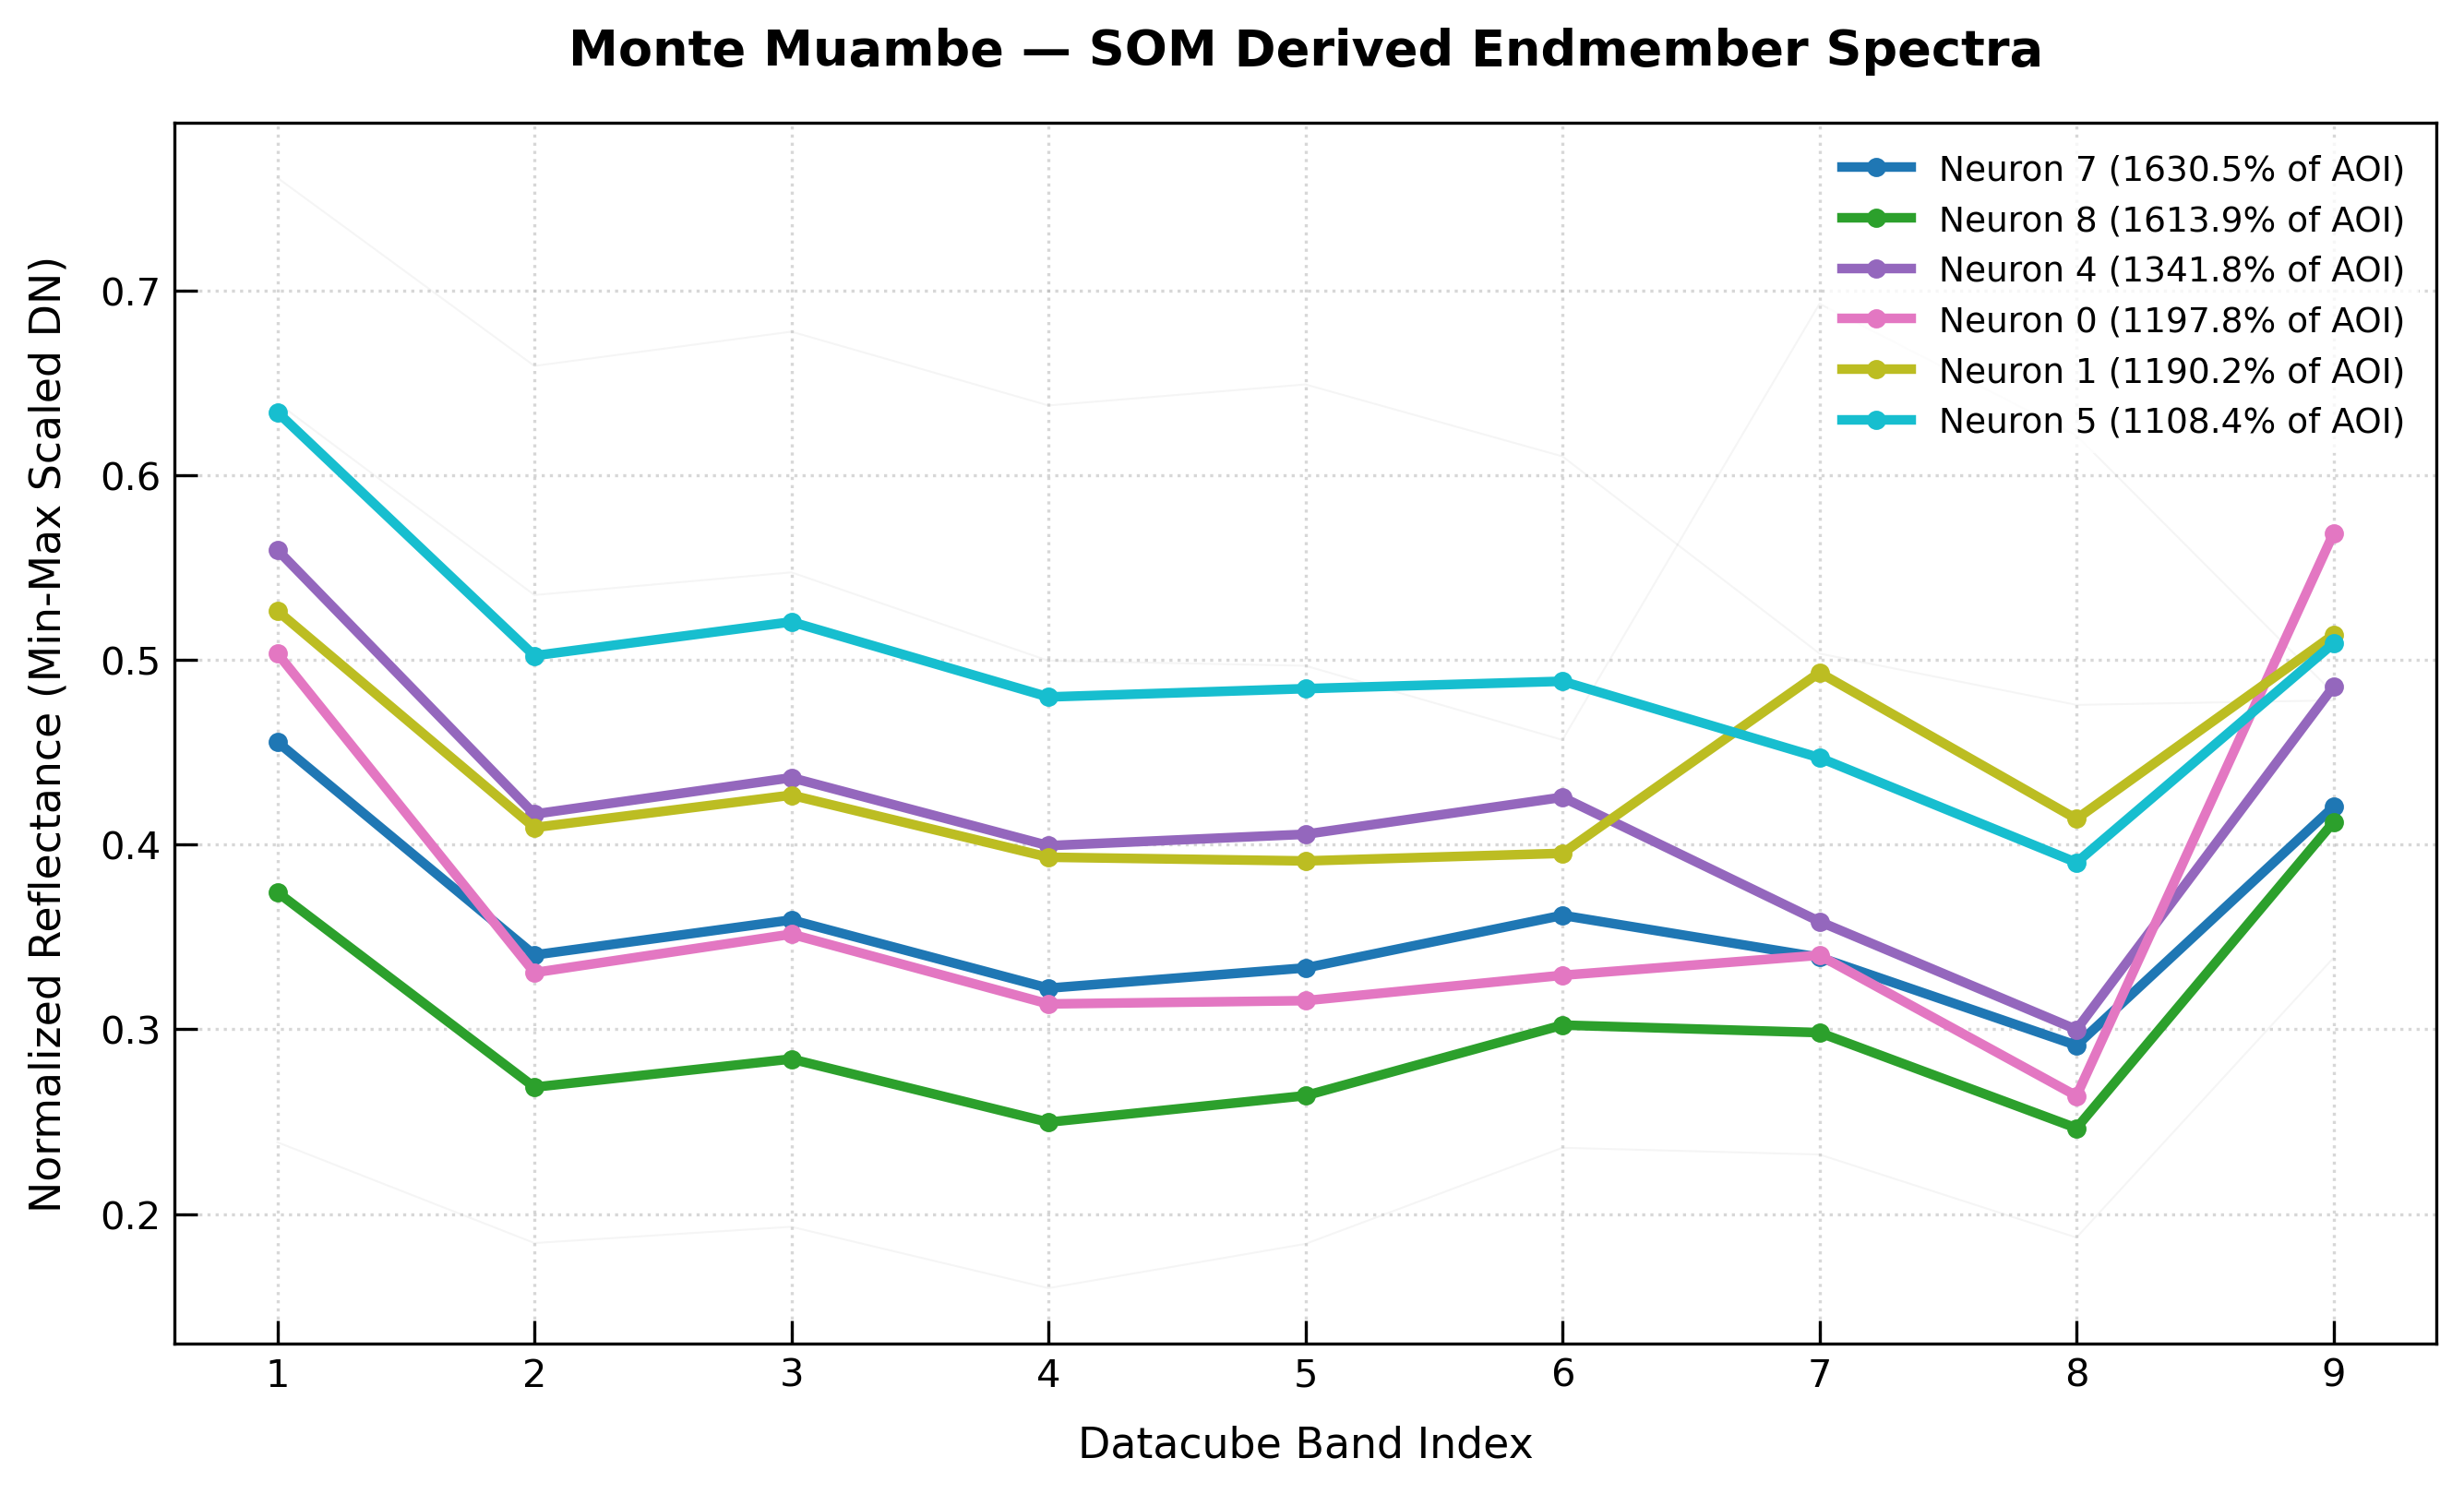

Saved → output/aster_som_spectral_curves.png


In [ ]:
# ---------------------------------------------------------------------------
# 14. EXTRACT & PLOT DOMINANT SPECTRAL CURVES (Publication Quality)
# ---------------------------------------------------------------------------

# 1. Get the final weights: shape is (n_neurons, n_bands)
w_final = som.weights_Kohonen.detach().cpu().numpy()
winner_counts = som.winner_counts  # how many pixels mapped to each neuron

# 2. Define your actual ASTER wavelengths (in micrometers) to make the plot physical.
# Adjust this list to match the exact bands present in your DATACUBE_PATH.
# Standard ASTER: VNIR (B1=0.56, B2=0.66, B3=0.81), SWIR (B4=1.65, B5=2.16, B6=2.21, B7=2.26, B8=2.33, B9=2.40)
# If your datacube only has the 6 SWIR bands, use those wavelengths instead:
aster_wavelengths = [1.65, 2.16, 2.21, 2.26, 2.33, 2.40] 

# Ensure the wavelength array matches your data dimensions
if len(aster_wavelengths) != w_final.shape[1]:
    print(f"\n[Warning] Wavelength list length ({len(aster_wavelengths)}) "
          f"does not match data bands ({w_final.shape[1]}). Using band indices instead.")
    aster_wavelengths = np.arange(1, w_final.shape[1] + 1)
    x_label = "Datacube Band Index"
else:
    x_label = "Wavelength (µm)"

# 3. Identify the Top 6 most dominant neurons (highest pixel counts)
n_top_dominant = 6
top_neuron_ids = np.argsort(winner_counts)[::-1][:n_top_dominant]

# 4. Setup a clean, publication-ready line plot
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

# Plot a subtle background shadow of ALL neurons to show the total spectral variance
for i in range(n_neurons):
    if winner_counts[i] > 0: # skip completely dead neurons
        ax.plot(aster_wavelengths, w_final[i, :], color='gray', alpha=0.08, linewidth=0.5, zorder=1)

# High-contrast color palette for our dominant endmembers
colors = cm.get_cmap("tab10", n_top_dominant)

# Plot the dominant cluster spectra with distinct lines
for idx, nid in enumerate(top_neuron_ids):
    pixel_pct = 100.0 * winner_counts[nid] / data_valid.shape[0]
    ax.plot(
        aster_wavelengths, 
        w_final[nid, :], 
        color=colors(idx), 
        linewidth=2.5, 
        linestyle='-',
        marker='o', 
        markersize=4,
        label=f"Neuron {nid} ({pixel_pct:.1f}% of AOI)",
        zorder=3
    )

# 5. Geoscientific Design & Formatting
ax.set_title("Monte Muambe — SOM Derived Endmember Spectra", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel(x_label, fontsize=11, labelpad=8)
ax.set_ylabel("Normalized Reflectance (Min-Max Scaled DN)", fontsize=11, labelpad=8)

# Format ticks properly for publications
ax.tick_params(axis='both', which='major', labelsize=10, direction='in', length=6)
ax.grid(True, linestyle=":", alpha=0.5)

# Place the legend cleanly outside or inside
ax.legend(fontsize=9, loc="upper right", frameon=True, facecolor='white', edgecolor='none')

# Adjust layout and save
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/aster_som_spectral_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved → {OUTPUT_DIR}/aster_som_spectral_curves.png")/